# SpectraLoRA — Publication Figures

Reproduces all paper figures from pre-computed CSVs in `artifacts/`.

**Requires:** `arcadia_pycolor`, `pandas`, `matplotlib`, `scipy`, `numpy`  
Set `REPO_ROOT` below if the repo is not at the default path.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import display, Image, Markdown
from scipy.stats import pearsonr

DATA_DIR = Path('./artifacts')
FIG_DIR = Path('./output')

# Original Wong colors (to match existing plots for comparison)
WONG = {
    'blue': '#0072B2', 'orange': '#E69F00', 'green': '#009E73',
    'vermillion': '#D55E00', 'sky_blue': '#56B4E9', 'purple': '#CC79A7',
    'black': '#000000', 'yellow': '#F0E442'
}
C_REF = WONG['black']
C_PRED = WONG['blue']
C_EXP = WONG['vermillion']
C_FP = WONG['green']
C_ACC = WONG['sky_blue']
C_WARN = WONG['orange']
PALETTE = [WONG['blue'], WONG['vermillion'], WONG['green'], WONG['orange'], WONG['purple'], WONG['sky_blue']]

BENCHMARK_DISPLAY = {
    'dft_raw_line': 'DFT Raw Modes',
    'dft_peak': 'DFT Resolved Peaks',
    'experimental_peak': 'Experimental',
}

REGION_DISPLAY = {
    'fingerprint': 'Fingerprint (400–1800 cm⁻¹)',
    'full': 'Full Range',
    'fp_400_800': '400–800 cm⁻¹',
    'fp_800_1200': '800–1200 cm⁻¹',
    'fp_1200_1600': '1200–1600 cm⁻¹',
    'fp_1600_1800': '1600–1800 cm⁻¹',
    'measured_support': 'Measured Support',
}

print(f'FIG_DIR = {FIG_DIR}')
print(f'DATA_DIR = {DATA_DIR}')
REPO_ROOT = Path('/Users/rahul/Desktop/hp-proteins-ml')  # ← update if repo moved


FIG_DIR = output
DATA_DIR = artifacts


In [2]:
# === ARCADIA SCIENCE STYLE SETUP ===
import arcadia_pycolor as apc
apc.mpl.setup()
from matplotlib.ticker import FuncFormatter
import matplotlib as mpl

# ── Arcadia colors (from style guide) ──
AEGEAN    = '#5088C5'
AMBER     = '#F28360'
CANARY    = '#F7B846'
ASTER     = '#7A77AB'
SEAWEED   = '#3B9886'
DRAGON    = '#C85152'
VITAL     = '#73B5E3'
LIME      = '#97CD78'
ROSE      = '#F898AE'
TANGERINE = '#FFB883'
OAT       = '#F5E4BE'
WISH      = '#BABEE0'

# Neutrals
A_BLACK   = '#09090A'
CHARCOAL  = '#484B50'
MARINE    = '#8A99AD'
CHATEAU   = '#B9AFA7'
BARK      = '#8F8885'
SLATE     = '#43413F'
GRAY      = '#EBEDE8'

# Background
PARCHMENT = '#FEF7F1'

# Shades (for supporting elements)
SKY       = '#C6E7F4'
LAPIS     = '#2B66A2'
DUSK      = '#094468'

A_PALETTE = [AEGEAN, AMBER, SEAWEED, CANARY, ASTER, DRAGON]

# ── Number formatter ──
def _comma_fmt(x, p):
    if abs(x) >= 1000:
        return f'{x:,.0f}'
    elif x == int(x) and abs(x) >= 1:
        return f'{int(x)}'
    elif abs(x) >= 1:
        return f'{x:g}'
    elif x == 0:
        return '0'
    else:
        return f'{x:.2g}'

# ── Core style function ──
def arcadia_style(ax, panel_letter=None, comma_x=True, comma_y=True):
    """Apply full Arcadia style to an axes."""
    ax.set_facecolor(PARCHMENT)
    for sp in ['top', 'right']:
        ax.spines[sp].set_visible(False)
    for sp in ['left', 'bottom']:
        ax.spines[sp].set_linewidth(0.75)
        ax.spines[sp].set_color(A_BLACK)
    ax.tick_params(axis='both', which='major', length=5, width=0.75,
                   color=A_BLACK, labelsize=12, direction='out', pad=5)
    ax.tick_params(axis='both', which='minor', length=3, width=0.5, direction='out')
    ax.grid(False)
    if comma_x:
        ax.xaxis.set_major_formatter(FuncFormatter(_comma_fmt))
    if comma_y:
        ax.yaxis.set_major_formatter(FuncFormatter(_comma_fmt))
    if panel_letter:
        ax.text(-0.08, 1.06, panel_letter, transform=ax.transAxes,
                fontsize=30, fontweight='bold', color=CHATEAU, va='top', ha='left')
    try:
        apc.mpl.style_plot(ax, monospaced_axes='both')
    except Exception:
        pass

# ── Figure creator ──
def arcadia_fig(nrows=1, ncols=1, figsize=None, **kwargs):
    if figsize is None:
        figsize = (7 * ncols, 5.5 * nrows)
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize, **kwargs)
    fig.set_facecolor('white')
    return fig, axes

# ── Legend: Arcadia "Key" style ──
# - No frame box, transparent on parchment
# - Bold title with chateau underline
# - Positioned in corner, NOT overlapping data
# - Use loc='upper right' or bbox_to_anchor to place outside data area
def arcadia_legend(ax, title=None, loc='upper right', outside=False, **kwargs):
    """Arcadia-style legend (Key). 
    Set outside=True to place legend outside the axes entirely."""
    leg_kwargs = dict(
        frameon=False, fontsize=11, loc=loc,
        borderpad=0.5, handlelength=1.5, labelspacing=0.3,
        handletextpad=0.5
    )
    if outside:
        leg_kwargs['bbox_to_anchor'] = (1.02, 1)
        leg_kwargs['loc'] = 'upper left'
    leg_kwargs.update(kwargs)
    if title:
        leg_kwargs['title'] = title
        leg_kwargs['title_fontproperties'] = {'weight': 'bold', 'size': 13}
    leg = ax.legend(**leg_kwargs)
    if title and leg.get_title():
        leg.get_title().set_color(A_BLACK)
    return leg

# ── Global defaults ──
mpl.rcParams['lines.linewidth'] = 2.0
mpl.rcParams['lines.markersize'] = 6
mpl.rcParams['scatter.marker'] = 'o'
mpl.rcParams['axes.facecolor'] = PARCHMENT
mpl.rcParams['figure.facecolor'] = 'white'

print('Arcadia style setup ready.')
print(f'  Parchment: {PARCHMENT}')
print(f'  Primary palette: {A_PALETTE}')

Arcadia style setup ready.
  Parchment: #FEF7F1
  Primary palette: ['#5088C5', '#F28360', '#3B9886', '#F7B846', '#7A77AB', '#C85152']


In [3]:
ll = pd.read_csv(DATA_DIR / 'stats_line_level_matches.csv')
pm = pd.read_csv(DATA_DIR / 'stats_per_molecule.csv')
pw = pd.read_csv(DATA_DIR / 'stats_pairwise_region_summary.csv')
sc = pd.read_csv(DATA_DIR / 'stats_scale_sweep.csv')

dft_pm = pm[pm['benchmark_group'] == 'dft'].copy()
exp_pm = pm[pm['benchmark_group'] == 'experimental'].copy()

print(f'Line-level: {len(ll):,} rows')
print(f'Per-molecule: {len(pm):,} rows ({len(dft_pm)} DFT, {len(exp_pm)} exp)')
print(f'Pairwise summary: {len(pw):,} rows')
print(f'Scale sweep: {len(sc):,} rows')

Line-level: 2,034,421 rows
Per-molecule: 601 rows (512 DFT, 89 exp)
Pairwise summary: 1,152 rows
Scale sweep: 152 rows


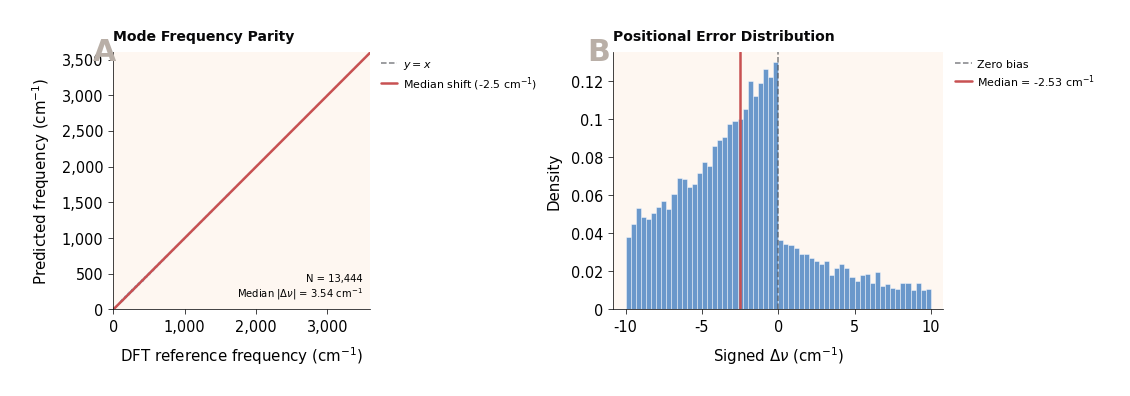

[Arcadia] fig1_frequency_parity: N=13,444 matched modes


In [4]:
# === ARCADIA: Figure 1 — Frequency Parity + Signed Error ===
from matplotlib.colors import LinearSegmentedColormap

src_col = 'source_freq_cm' if 'source_freq_cm' in ll.columns else 'source_freq'
tgt_col = 'target_freq_cm' if 'target_freq_cm' in ll.columns else 'target_freq'
dnu_col = 'signed_dnu_cm' if 'signed_dnu_cm' in ll.columns else 'signed_dnu'

dft_raw = ll[(ll['benchmark'] == 'dft_raw_line') & (ll['pair'] == 'DFT->Pred') &
              (ll['region'] == 'full') & (ll['tol_cm'] == 10.0)]

fig, axes = arcadia_fig(1, 2, figsize=(15.6, 5.3))

# --- Panel A: Parity hexbin ---
ax = axes[0]
cmap_arc = LinearSegmentedColormap.from_list('arc_blues', ['#F4FBFE', AEGEAN, '#2B66A2'])
ax.hexbin(dft_raw[src_col], dft_raw[tgt_col], gridsize=80, cmap=cmap_arc, mincnt=1, linewidths=0.1)
lim = [0, 3600]
ax.plot(lim, lim, color=CHARCOAL, lw=1.5, ls='--', alpha=0.7, label='$y = x$')
med_line = np.median(dft_raw[dnu_col].dropna())
ax.plot(lim, [l + med_line for l in lim], color=DRAGON, lw=2.5, ls='-',
        label=f'Median shift ({med_line:+.1f} cm$^{{-1}}$)')
ax.set_xlabel(r'DFT reference frequency (cm$^{-1}$)', fontsize=15, fontweight='medium')
ax.set_ylabel(r'Predicted frequency (cm$^{-1}$)', fontsize=15, fontweight='medium')
ax.set_xlim(lim); ax.set_ylim(lim)
ax.set_aspect('equal')
n_matched = len(dft_raw)
med_err = np.median(np.abs(dft_raw[dnu_col].dropna()))
ax.text(0.97, 0.03, f'N = {n_matched:,}\nMedian |$\\Delta\\nu$| = {med_err:.2f} cm$^{{-1}}$',
        transform=ax.transAxes, fontsize=10, ha='right', va='bottom',
        bbox=dict(boxstyle='round,pad=0.4', facecolor=PARCHMENT, edgecolor=CHATEAU, alpha=0.9))
arcadia_style(ax, panel_letter='A')
ax.set_title('Mode Frequency Parity', fontsize=14, fontweight='semibold', color=A_BLACK, pad=12, loc='left')
arcadia_legend(ax, outside=True)

# --- Panel B: Signed error histogram ---
ax = axes[1]
vals = dft_raw[dnu_col].dropna().values
ax.hist(vals, bins=60, range=(-10, 10), color=AEGEAN, alpha=0.85, density=True,
        edgecolor='white', linewidth=0.5)
ax.axvline(0, color=CHARCOAL, lw=1.5, ls='--', alpha=0.7, label='Zero bias')
med_val = np.median(vals)
ax.axvline(med_val, color=DRAGON, lw=2.5, ls='-',
           label=f'Median = {med_val:+.2f} cm$^{{-1}}$')
ax.set_xlabel(r'Signed $\Delta\nu$ (cm$^{-1}$)', fontsize=15, fontweight='medium')
ax.set_ylabel('Density', fontsize=15, fontweight='medium')
arcadia_style(ax, panel_letter='B')
ax.set_title('Positional Error Distribution', fontsize=14, fontweight='semibold', color=A_BLACK, pad=12, loc='left')
arcadia_legend(ax, outside=True)

fig.tight_layout(pad=1.5)
fig.subplots_adjust(right=0.82)
fig.savefig(FIG_DIR / 'fig1_frequency_parity_arcadia.png', dpi=300, bbox_inches='tight', facecolor='white')
fig.savefig(FIG_DIR / 'fig1_frequency_parity_arcadia.svg', bbox_inches='tight', facecolor='white')
fig.savefig(FIG_DIR / 'fig1_frequency_parity_arcadia.pdf', bbox_inches='tight', facecolor='white')
plt.show()
print(f'[Arcadia] fig1_frequency_parity: N={n_matched:,} matched modes')

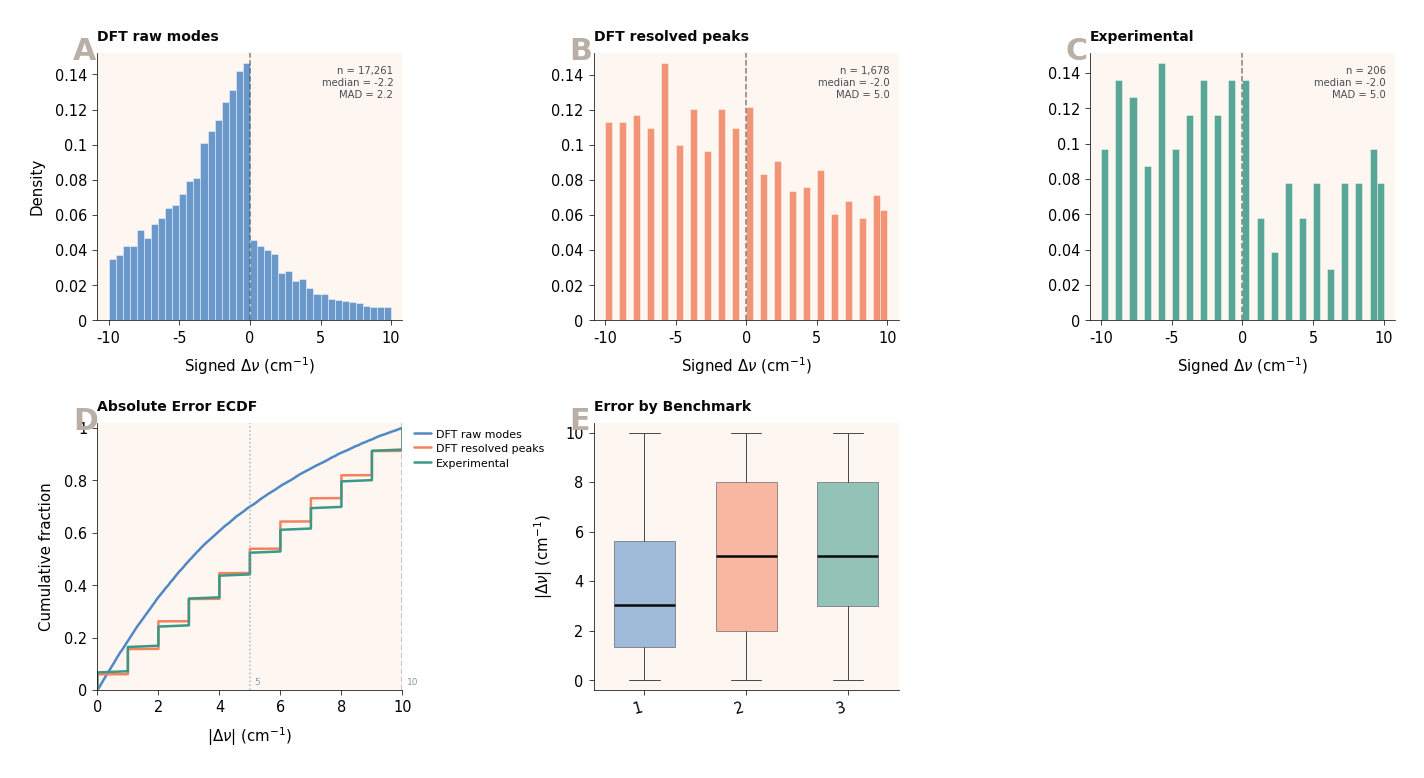

[Arcadia] fig2_error_distributions done


In [5]:
# === ARCADIA: Figure 2 — Error Distributions (split histograms) ===
dnu_col = 'signed_dnu_cm' if 'signed_dnu_cm' in ll.columns else 'signed_dnu'

benchmarks = [
    ('dft_raw_line', 'DFT->Pred', 'fingerprint', 'DFT raw modes', AEGEAN),
    ('dft_peak', 'DFT->Pred', 'fingerprint', 'DFT resolved peaks', AMBER),
    ('experimental_peak', 'Exp->Pred', 'fingerprint', 'Experimental', SEAWEED),
]

fig, axes = arcadia_fig(2, 3, figsize=(23.5, 10.6))

# ── Top row (A, B, C): Individual signed-error histograms ──
for col_idx, (bm, pair, region, label, color) in enumerate(benchmarks):
    ax = axes[0, col_idx]
    subset = ll[(ll['benchmark'] == bm) & (ll['pair'] == pair) &
                 (ll['region'] == region) & (ll['tol_cm'] == 10.0)]
    if dnu_col not in subset.columns or len(subset) == 0:
        continue
    vals = subset[dnu_col].dropna().values

    ax.hist(vals, bins=40, range=(-10, 10), alpha=0.85, color=color,
            density=True, edgecolor='white', linewidth=0.5)
    ax.axvline(0, color=CHARCOAL, lw=1.5, ls='--', alpha=0.7)

    # Stats annotation
    med = np.median(vals)
    mad = np.median(np.abs(vals - med))
    ax.text(0.97, 0.95, f'n = {len(vals):,}\nmedian = {med:+.1f}\nMAD = {mad:.1f}',
            transform=ax.transAxes, fontsize=10, va='top', ha='right',
            color=CHARCOAL, family='monospace')

    ax.set_xlabel(r'Signed $\Delta\nu$ (cm$^{-1}$)', fontsize=15, fontweight='medium')
    if col_idx == 0:
        ax.set_ylabel('Density', fontsize=15, fontweight='medium')
    panel = chr(ord('A') + col_idx)
    arcadia_style(ax, panel_letter=panel)
    ax.set_title(label, fontsize=14, fontweight='semibold', color=A_BLACK, pad=12, loc='left')

# ── Bottom-left (D): Raw ECDF ──
ax_ecdf = axes[1, 0]

for bm, pair, region, label, color in benchmarks:
    subset = ll[(ll['benchmark'] == bm) & (ll['pair'] == pair) &
                 (ll['region'] == region) & (ll['tol_cm'] == 10.0)]
    if dnu_col not in subset.columns or len(subset) == 0:
        continue
    abs_vals = np.sort(np.abs(subset[dnu_col].dropna().values))
    ecdf = np.arange(1, len(abs_vals)+1) / len(abs_vals)
    ax_ecdf.plot(abs_vals, ecdf, color=color, label=label, lw=2.5)

for thr, ls in [(5, ':'), (10, '--')]:
    ax_ecdf.axvline(thr, color=MARINE, lw=1.5, ls=ls, alpha=0.7)
    ax_ecdf.text(thr + 0.15, 0.02, f'{thr}', fontsize=9, color=MARINE)

ax_ecdf.set_xlabel(r'|$\Delta\nu$| (cm$^{-1}$)', fontsize=15, fontweight='medium')
ax_ecdf.set_ylabel('Cumulative fraction', fontsize=15, fontweight='medium')
ax_ecdf.set_xlim(0, 10)
ax_ecdf.set_ylim(0, 1.02)
arcadia_style(ax_ecdf, panel_letter='D')
ax_ecdf.set_title('Absolute Error ECDF', fontsize=14, fontweight='semibold', color=A_BLACK, pad=12, loc='left')
arcadia_legend(ax_ecdf, outside=True)

# ── Bottom-center (E): Boxplots ──
ax_box = axes[1, 1]
box_data, box_labels, box_colors = [], [], []
for bm, pair, region, label, color in benchmarks:
    subset = ll[(ll['benchmark'] == bm) & (ll['pair'] == pair) &
                 (ll['region'] == region) & (ll['tol_cm'] == 10.0)]
    if dnu_col in subset.columns and len(subset) > 0:
        box_data.append(np.abs(subset[dnu_col].dropna().values))
        box_labels.append(label)
        box_colors.append(color)

if box_data:
    bp = ax_box.boxplot(box_data, patch_artist=True, widths=0.6,
                        medianprops=dict(color=A_BLACK, lw=2.5),
                        whiskerprops=dict(color=CHARCOAL), capprops=dict(color=CHARCOAL),
                        flierprops=dict(marker='.', markersize=2, alpha=0.3, color=CHARCOAL))
    for patch, color in zip(bp['boxes'], box_colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.55)
        patch.set_edgecolor(CHARCOAL)
    ax_box.set_xticklabels(box_labels, fontsize=10, rotation=15, ha='right')
    ax_box.set_ylabel(r'|$\Delta\nu$| (cm$^{-1}$)', fontsize=15, fontweight='medium')
arcadia_style(ax_box, panel_letter='E')
ax_box.set_title('Error by Benchmark', fontsize=14, fontweight='semibold', color=A_BLACK, pad=12, loc='left')

# ── Hide bottom-right (empty) ──
axes[1, 2].set_visible(False)

fig.tight_layout(pad=1.5)
fig.subplots_adjust(right=0.82)
fig.savefig(FIG_DIR / 'fig2_error_distributions_arcadia.png', dpi=300, bbox_inches='tight', facecolor='white')
fig.savefig(FIG_DIR / 'fig2_error_distributions_arcadia.svg', bbox_inches='tight', facecolor='white')
fig.savefig(FIG_DIR / 'fig2_error_distributions_arcadia.pdf', bbox_inches='tight', facecolor='white')
plt.show()
print('[Arcadia] fig2_error_distributions done')

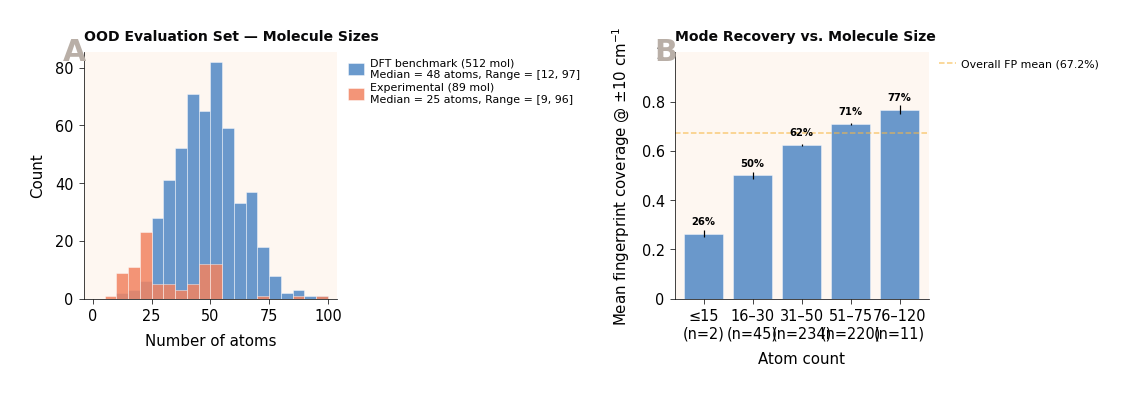

[Arcadia] fig3_molecule_sizes done


In [6]:
# === ARCADIA: Figure 3 — Molecule Sizes ===
fig, axes = arcadia_fig(1, 2, figsize=(15.6, 5.3))

# Panel A: Atom count distribution
for bg, color, label in [('dft', AEGEAN, 'DFT benchmark (512 mol)'),
                           ('experimental', AMBER, 'Experimental (89 mol)')]:
    subset = pm[pm['benchmark_group'] == bg]['n_atoms'].dropna()
    if len(subset) > 0:
        axes[0].hist(subset, bins=range(0, int(subset.max())+5, 5), alpha=0.85,
                    color=color, edgecolor='white', linewidth=0.5,
                    label=f'{label}\nMedian = {int(subset.median())} atoms, Range = [{int(subset.min())}, {int(subset.max())}]')
axes[0].set_xlabel('Number of atoms', fontsize=15, fontweight='medium')
axes[0].set_ylabel('Count', fontsize=15, fontweight='medium')
arcadia_style(axes[0], panel_letter='A')
axes[0].set_title('OOD Evaluation Set — Molecule Sizes', fontsize=14, fontweight='semibold', color=A_BLACK, pad=12, loc='left')
arcadia_legend(axes[0], outside=True)

# Panel B: Coverage vs molecule size
dft_mols = pm[pm['benchmark_group'] == 'dft'].copy()
cov_col = [c for c in dft_mols.columns if 'coverage_any__dft_raw_line__DFT->Pred__fingerprint__tol_10' in c]
if cov_col:
    dft_mols['fp_cov'] = dft_mols[cov_col[0]]
    dft_mols['size_bin'] = pd.cut(dft_mols['n_atoms'], bins=[0, 15, 30, 50, 75, 120],
                                   labels=['\u226415', '16\u201330', '31\u201350', '51\u201375', '76\u2013120'])
    bin_stats = dft_mols.groupby('size_bin', observed=True)['fp_cov'].agg(['mean', 'count', 'std', 'median'])

    x = range(len(bin_stats))
    bars = axes[1].bar(x, bin_stats['mean'], yerr=bin_stats['std']/np.sqrt(bin_stats['count']),
                       color=AEGEAN, alpha=0.85, edgecolor='white', linewidth=0.5, capsize=4, error_kw={'lw': 1.2})
    axes[1].set_xticks(list(x))
    axes[1].set_xticklabels([f'{idx}\n(n={int(row["count"])})' for idx, row in bin_stats.iterrows()], fontsize=9)
    axes[1].set_xlabel('Atom count', fontsize=15, fontweight='medium')
    axes[1].set_ylabel(r'Mean fingerprint coverage @ $\pm$10 cm$^{-1}$', fontsize=15, fontweight='medium')
    axes[1].set_ylim(0, 1.0)
    axes[1].axhline(0.672, color=CANARY, lw=1.5, ls='--', alpha=0.7, label='Overall FP mean (67.2%)')

    for bar, val in zip(bars, bin_stats['mean']):
        axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.03,
                    f'{val:.0%}', ha='center', va='bottom', fontsize=10, fontweight='bold')
else:
    axes[1].text(0.5, 0.5, 'Coverage column not found', ha='center', va='center',
                transform=axes[1].transAxes, fontsize=11, color=MARINE)
arcadia_style(axes[1], panel_letter='B', comma_x=False)
axes[1].set_title('Mode Recovery vs. Molecule Size', fontsize=14, fontweight='semibold', color=A_BLACK, pad=12, loc='left')
arcadia_legend(axes[1], outside=True)


fig.tight_layout(pad=1.5)
fig.subplots_adjust(right=0.82)
fig.savefig(FIG_DIR / 'fig3_molecule_sizes_arcadia.png', dpi=300, bbox_inches='tight', facecolor='white')
fig.savefig(FIG_DIR / 'fig3_molecule_sizes_arcadia.svg', bbox_inches='tight', facecolor='white')
fig.savefig(FIG_DIR / 'fig3_molecule_sizes_arcadia.pdf', bbox_inches='tight', facecolor='white')
plt.show()
print('[Arcadia] fig3_molecule_sizes done')

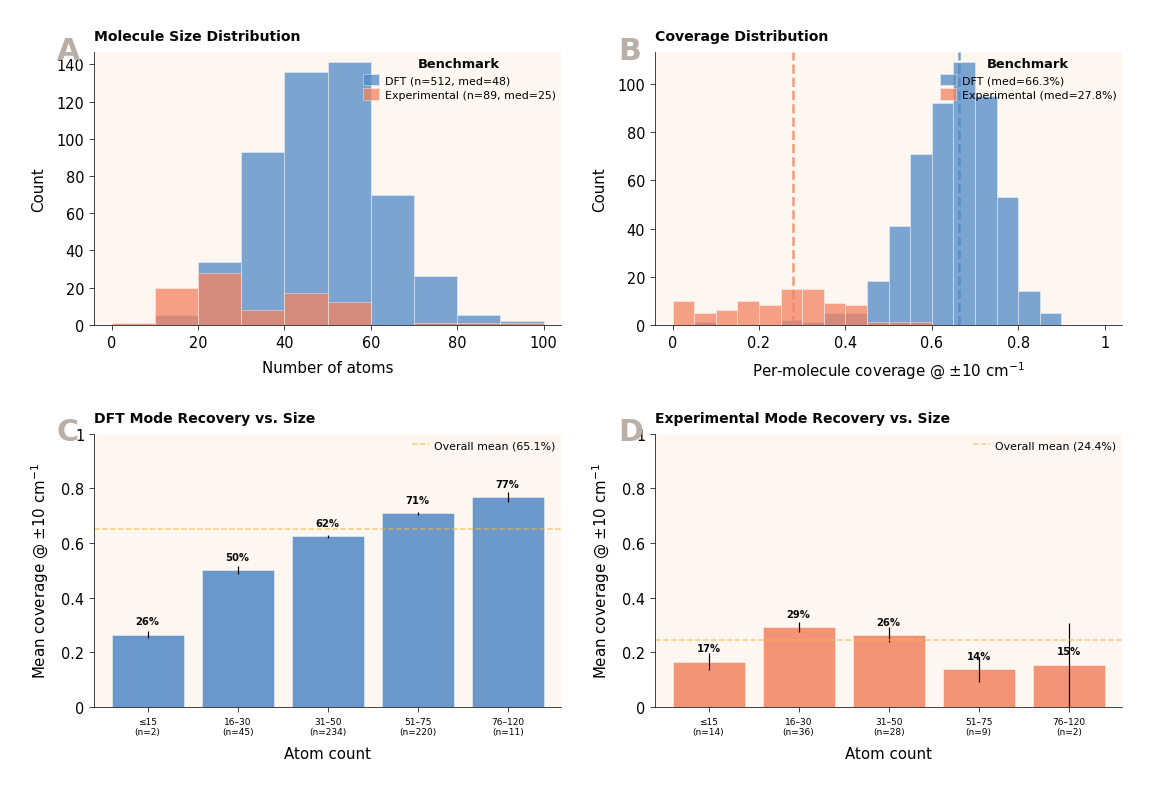

[Arcadia] Fig 3 alt: DFT cov median=66.3%, Exp cov median=27.8%


In [7]:
# === ARCADIA: Figure 3 (alt) — DFT vs Experimental, 4-panel ===

dft_cov_col = 'coverage_any__dft_raw_line__DFT->Pred__fingerprint__tol_10'
exp_cov_col = 'coverage_any__experimental_peak__Exp->Pred__measured_support__tol_10'

fig, axes = arcadia_fig(2, 2, figsize=(16, 11))

# ── Panel A: Atom count distributions (overlaid, 10-atom bins) ──
ax = axes[0, 0]
atom_bins = range(0, 105, 10)  # 0, 10, 20, ..., 100
dft_atoms = dft_pm['n_atoms'].dropna()
exp_atoms = exp_pm['n_atoms'].dropna()
ax.hist(dft_atoms, bins=atom_bins, alpha=0.75, color=AEGEAN, edgecolor='white', linewidth=0.5,
        label=f'DFT (n={len(dft_atoms)}, med={int(dft_atoms.median())})')
ax.hist(exp_atoms, bins=atom_bins, alpha=0.75, color=AMBER, edgecolor='white', linewidth=0.5,
        label=f'Experimental (n={len(exp_atoms)}, med={int(exp_atoms.median())})')
ax.set_xlabel('Number of atoms', fontsize=15, fontweight='medium')
ax.set_ylabel('Count', fontsize=15, fontweight='medium')
arcadia_style(ax, panel_letter='A')
ax.set_title('Molecule Size Distribution', fontsize=14, fontweight='semibold', color=A_BLACK, pad=12, loc='left')
arcadia_legend(ax, title='Benchmark', loc='upper right')

# ── Panel B: Coverage histograms (overlaid) ──
ax = axes[0, 1]
dft_cov = dft_pm[dft_cov_col].dropna().values
exp_cov = exp_pm[exp_cov_col].dropna().values
ax.hist(dft_cov, bins=20, range=(0, 1), alpha=0.75, color=AEGEAN, edgecolor='white', linewidth=0.5,
        label=f'DFT (med={np.median(dft_cov):.1%})')
ax.hist(exp_cov, bins=20, range=(0, 1), alpha=0.75, color=AMBER, edgecolor='white', linewidth=0.5,
        label=f'Experimental (med={np.median(exp_cov):.1%})')
ax.axvline(np.median(dft_cov), color=AEGEAN, lw=2.5, ls='--', alpha=0.8)
ax.axvline(np.median(exp_cov), color=AMBER, lw=2.5, ls='--', alpha=0.8)
ax.set_xlabel(r'Per-molecule coverage @ $\pm$10 cm$^{-1}$', fontsize=15, fontweight='medium')
ax.set_ylabel('Count', fontsize=15, fontweight='medium')
arcadia_style(ax, panel_letter='B')
ax.set_title('Coverage Distribution', fontsize=14, fontweight='semibold', color=A_BLACK, pad=12, loc='left')
arcadia_legend(ax, title='Benchmark', loc='upper right')

# ── Panel C: DFT mode recovery vs molecule size ──
ax = axes[1, 0]
dft_mols = dft_pm.copy()
dft_mols['fp_cov'] = dft_mols[dft_cov_col]
dft_mols['size_bin'] = pd.cut(dft_mols['n_atoms'], bins=[0, 15, 30, 50, 75, 120],
                               labels=['\u226415', '16\u201330', '31\u201350', '51\u201375', '76\u2013120'])
dft_bin = dft_mols.groupby('size_bin', observed=True)['fp_cov'].agg(['mean', 'count', 'std'])
x = range(len(dft_bin))
bars = ax.bar(x, dft_bin['mean'], yerr=dft_bin['std']/np.sqrt(dft_bin['count']),
              color=AEGEAN, alpha=0.85, edgecolor='white', linewidth=0.5, capsize=4, error_kw={'lw': 1.2})
ax.set_xticks(list(x))
ax.set_xticklabels([f'{idx}\n(n={int(row["count"])})' for idx, row in dft_bin.iterrows()], fontsize=9)
ax.set_xlabel('Atom count', fontsize=15, fontweight='medium')
ax.set_ylabel(r'Mean coverage @ $\pm$10 cm$^{-1}$', fontsize=15, fontweight='medium')
ax.set_ylim(0, 1.0)
overall_dft = np.mean(dft_cov)
ax.axhline(overall_dft, color=CANARY, lw=1.5, ls='--', alpha=0.7, label=f'Overall mean ({overall_dft:.1%})')
for bar, val in zip(bars, dft_bin['mean']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.03,
            f'{val:.0%}', ha='center', va='bottom', fontsize=10, fontweight='bold', color=A_BLACK)
arcadia_style(ax, panel_letter='C', comma_x=False)
ax.set_xticks(list(x))
ax.set_xticklabels([f'{idx}\n(n={int(row["count"])})' for idx, row in dft_bin.iterrows()], fontsize=9)
ax.set_title('DFT Mode Recovery vs. Size', fontsize=14, fontweight='semibold', color=A_BLACK, pad=12, loc='left')
arcadia_legend(ax, loc='upper right')

# ── Panel D: Experimental mode recovery vs molecule size ──
ax = axes[1, 1]
exp_mols = exp_pm.copy()
exp_mols['fp_cov'] = exp_mols[exp_cov_col]
exp_mols['size_bin'] = pd.cut(exp_mols['n_atoms'], bins=[0, 15, 30, 50, 75, 120],
                               labels=['\u226415', '16\u201330', '31\u201350', '51\u201375', '76\u2013120'])
exp_bin = exp_mols.groupby('size_bin', observed=True)['fp_cov'].agg(['mean', 'count', 'std'])
x = range(len(exp_bin))
bars = ax.bar(x, exp_bin['mean'], yerr=exp_bin['std']/np.sqrt(exp_bin['count']),
              color=AMBER, alpha=0.85, edgecolor='white', linewidth=0.5, capsize=4, error_kw={'lw': 1.2})
ax.set_xticks(list(x))
ax.set_xticklabels([f'{idx}\n(n={int(row["count"])})' for idx, row in exp_bin.iterrows()], fontsize=9)
ax.set_xlabel('Atom count', fontsize=15, fontweight='medium')
ax.set_ylabel(r'Mean coverage @ $\pm$10 cm$^{-1}$', fontsize=15, fontweight='medium')
ax.set_ylim(0, 1.0)
overall_exp = np.mean(exp_cov)
ax.axhline(overall_exp, color=CANARY, lw=1.5, ls='--', alpha=0.7, label=f'Overall mean ({overall_exp:.1%})')
for bar, val in zip(bars, exp_bin['mean']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.03,
            f'{val:.0%}', ha='center', va='bottom', fontsize=10, fontweight='bold', color=A_BLACK)
arcadia_style(ax, panel_letter='D', comma_x=False)
ax.set_xticks(list(x))
ax.set_xticklabels([f'{idx}\n(n={int(row["count"])})' for idx, row in exp_bin.iterrows()], fontsize=9)
ax.set_title('Experimental Mode Recovery vs. Size', fontsize=14, fontweight='semibold', color=A_BLACK, pad=12, loc='left')
arcadia_legend(ax, loc='upper right')

fig.tight_layout(pad=2.0)
fig.savefig(FIG_DIR / 'fig3_alt_dft_vs_exp_arcadia.png', dpi=300, bbox_inches='tight', facecolor='white')
fig.savefig(FIG_DIR / 'fig3_alt_dft_vs_exp_arcadia.svg', bbox_inches='tight', facecolor='white')
fig.savefig(FIG_DIR / 'fig3_alt_dft_vs_exp_arcadia.pdf', bbox_inches='tight', facecolor='white')
plt.show()
print(f'[Arcadia] Fig 3 alt: DFT cov median={np.median(dft_cov):.1%}, Exp cov median={np.median(exp_cov):.1%}')

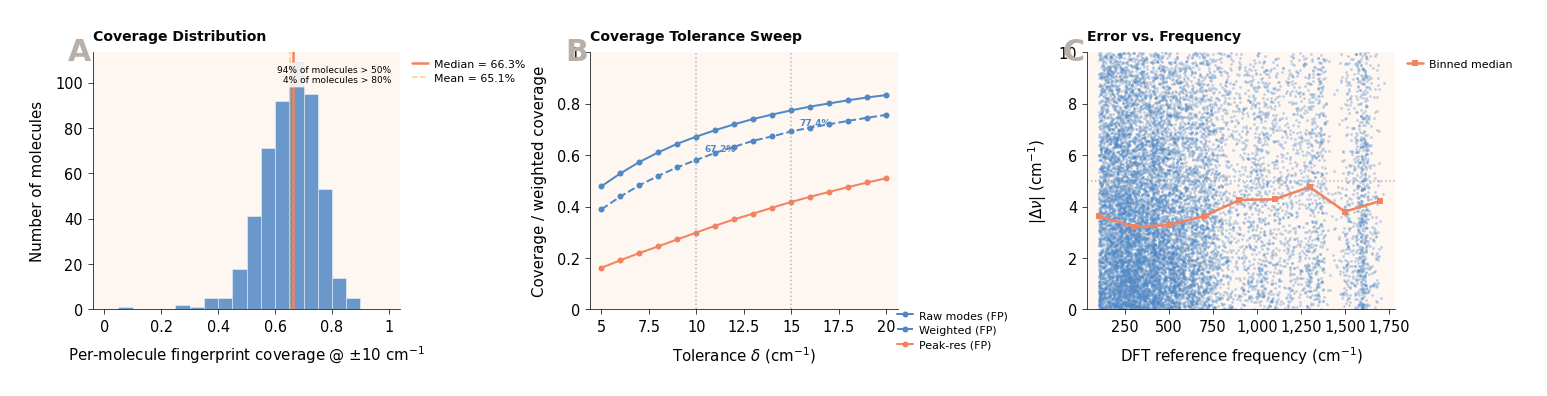

[Arcadia] fig4_narrative_plots done


In [8]:
# === ARCADIA: Figure 4 — Narrative Plots ===
# (a) Per-molecule coverage histogram  (b) Tolerance sweep from pw  (c) |dnu| vs frequency

fig, axes = arcadia_fig(1, 3, figsize=(23.5, 5.3))

# --- (a) Per-molecule fingerprint coverage histogram ---
ax = axes[0]
cov_col_name = [c for c in dft_pm.columns if 'coverage_any__dft_raw_line__DFT->Pred__fingerprint__tol_10' in c]
if cov_col_name and len(dft_pm) > 0:
    vals = dft_pm[cov_col_name[0]].dropna().values
    ax.hist(vals, bins=20, range=(0, 1), color=AEGEAN, alpha=0.85, edgecolor='white', linewidth=0.5)
    ax.axvline(np.median(vals), color=AMBER, lw=2.5, ls='-',
               label=f'Median = {np.median(vals):.1%}')
    ax.axvline(np.mean(vals), color=CANARY, lw=1.5, ls='--', alpha=0.7,
               label=f'Mean = {np.mean(vals):.1%}')
    pct_50 = np.mean(vals >= 0.5)
    pct_80 = np.mean(vals >= 0.8)
    ax.text(0.97, 0.95, f'{pct_50:.0%} of molecules > 50%\n{pct_80:.0%} of molecules > 80%',
            transform=ax.transAxes, fontsize=9, ha='right', va='top',
            bbox=dict(boxstyle='round,pad=0.3', facecolor=PARCHMENT, edgecolor=CHATEAU, alpha=0.9))
else:
    ax.text(0.5, 0.5, 'Coverage column not found', ha='center', va='center', transform=ax.transAxes)
ax.set_xlabel(r'Per-molecule fingerprint coverage @ $\pm$10 cm$^{-1}$', fontsize=15, fontweight='medium')
ax.set_ylabel('Number of molecules', fontsize=15, fontweight='medium')
arcadia_style(ax, panel_letter='A')
ax.set_title('Coverage Distribution', fontsize=14, fontweight='semibold', color=A_BLACK, pad=12, loc='left')
arcadia_legend(ax, outside=True)

# --- (b) Tolerance sweep from pairwise summary ---
ax = axes[1]
sweep_configs = [
    ('dft_raw_line', 'DFT->Pred', 'fingerprint', 'global_coverage_any', 'Raw modes (FP)', AEGEAN, '-'),
    ('dft_raw_line', 'DFT->Pred', 'fingerprint', 'global_weighted_coverage_any', 'Weighted (FP)', AEGEAN, '--'),
    ('dft_peak', 'DFT->Pred', 'fingerprint', 'global_coverage_any', 'Peak-res (FP)', AMBER, '-'),
]
for bm, pair, region, metric, label, color, ls in sweep_configs:
    data = pw[(pw['benchmark'] == bm) & (pw['pair'] == pair) &
              (pw['region'] == region) & (pw['snr_bin'] == 'all')].sort_values('tol_cm')
    if len(data) > 0:
        ax.plot(data['tol_cm'], data[metric], color=color, lw=2, ls=ls,
                marker='o', markersize=6, label=label)

for tol_mark in [10, 15]:
    ax.axvline(tol_mark, color=MARINE, lw=1.5, ls=':', alpha=0.7)

raw_fp_10 = pw[(pw['benchmark'] == 'dft_raw_line') & (pw['pair'] == 'DFT->Pred') &
               (pw['region'] == 'fingerprint') & (pw['snr_bin'] == 'all') & (pw['tol_cm'] == 10.0)]
if len(raw_fp_10) > 0:
    cov_at_10 = float(raw_fp_10['global_coverage_any'].iloc[0])
    ax.annotate(f'{cov_at_10:.1%}', (10, cov_at_10),
               textcoords='offset points', xytext=(8, -15), fontsize=9, fontweight='bold', color=AEGEAN)
raw_fp_15 = pw[(pw['benchmark'] == 'dft_raw_line') & (pw['pair'] == 'DFT->Pred') &
               (pw['region'] == 'fingerprint') & (pw['snr_bin'] == 'all') & (pw['tol_cm'] == 15.0)]
if len(raw_fp_15) > 0:
    cov_at_15 = float(raw_fp_15['global_coverage_any'].iloc[0])
    ax.annotate(f'{cov_at_15:.1%}', (15, cov_at_15),
               textcoords='offset points', xytext=(8, -15), fontsize=9, fontweight='bold', color=AEGEAN)

ax.set_xlabel(r'Tolerance $\delta$ (cm$^{-1}$)', fontsize=15, fontweight='medium')
ax.set_ylabel('Coverage / weighted coverage', fontsize=15, fontweight='medium')
ax.set_ylim(0, 1.0)
arcadia_style(ax, panel_letter='B')
ax.set_title('Coverage Tolerance Sweep', fontsize=14, fontweight='semibold', color=A_BLACK, pad=12, loc='left')
arcadia_legend(ax, loc='lower right', bbox_to_anchor=(0.98, 0.02), outside=True)

# --- (c) |dnu| vs reference frequency ---
ax = axes[2]
dnu_col = 'signed_dnu_cm' if 'signed_dnu_cm' in ll.columns else 'signed_dnu'
src_col = 'source_freq_cm' if 'source_freq_cm' in ll.columns else 'source_freq'

dft_fp = ll[(ll['benchmark'] == 'dft_raw_line') & (ll['pair'] == 'DFT->Pred') &
             (ll['region'] == 'full') & (ll['tol_cm'] == 10.0)]

if len(dft_fp) > 0 and dnu_col in dft_fp.columns and src_col in dft_fp.columns:
    freqs = dft_fp[src_col].values
    errs = np.abs(dft_fp[dnu_col].values)

    ax.scatter(freqs, errs, s=8, alpha=0.35, color=AEGEAN, rasterized=True)

    freq_bins = np.arange(0, 3600, 200)
    bin_meds, bin_centers = [], []
    for lo, hi in zip(freq_bins[:-1], freq_bins[1:]):
        mask_bin = (freqs >= lo) & (freqs < hi)
        if mask_bin.sum() >= 10:
            bin_meds.append(np.median(errs[mask_bin]))
            bin_centers.append((lo + hi) / 2)
    if bin_centers:
        ax.plot(bin_centers, bin_meds, color=AMBER, lw=2.5, marker='s', markersize=6,
                label='Binned median', zorder=5)

    ax.axhline(5, color=MARINE, lw=1.5, ls=':', alpha=0.7)
    ax.set_xlabel(r'DFT reference frequency (cm$^{-1}$)', fontsize=15, fontweight='medium')
    ax.set_ylabel(r'|$\Delta\nu$| (cm$^{-1}$)', fontsize=15, fontweight='medium')
    ax.set_ylim(0, 10)
arcadia_style(ax, panel_letter='C')
ax.set_title('Error vs. Frequency', fontsize=14, fontweight='semibold', color=A_BLACK, pad=12, loc='left')
arcadia_legend(ax, outside=True)

fig.tight_layout(pad=1.5)
fig.subplots_adjust(right=0.82)
fig.savefig(FIG_DIR / 'fig4_narrative_plots_arcadia.png', dpi=300, bbox_inches='tight', facecolor='white')
fig.savefig(FIG_DIR / 'fig4_narrative_plots_arcadia.svg', bbox_inches='tight', facecolor='white')
fig.savefig(FIG_DIR / 'fig4_narrative_plots_arcadia.pdf', bbox_inches='tight', facecolor='white')
plt.show()
print('[Arcadia] fig4_narrative_plots done')

/var/folders/8l/vgsnzp1s0g54ndf86zjdlwc00000gn/T/ipykernel_53885/1854222747.py:45: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot([box_data[r] for r in bp_order], labels=bp_order,


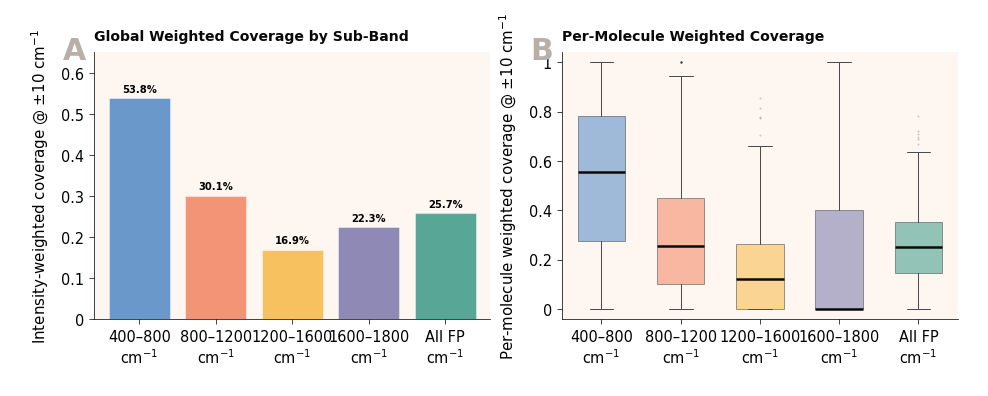

[Arcadia] fig5_subband_coverage done


In [9]:
# === ARCADIA: Figure 5 — Sub-Band Coverage ===
sub = pw[(pw['benchmark'] == 'dft_peak') & (pw['pair'] == 'DFT->Pred') & (pw['tol_cm'] == 10.0) &
         (pw['region'].isin(['fp_400_800', 'fp_800_1200', 'fp_1200_1600', 'fp_1600_1800', 'fingerprint'])) &
         (pw['snr_bin'] == 'all')].copy()

region_labels = {'fp_400_800': '400\u2013800', 'fp_800_1200': '800\u20131200',
                 'fp_1200_1600': '1200\u20131600', 'fp_1600_1800': '1600\u20131800', 'fingerprint': 'All FP'}
order = ['400\u2013800', '800\u20131200', '1200\u20131600', '1600\u20131800', 'All FP']
band_colors = [AEGEAN, AMBER, CANARY, ASTER, SEAWEED]

wt_cov_col = 'global_weighted_coverage_any' if 'global_weighted_coverage_any' in sub.columns else 'weighted_coverage_any_global'

sub['label'] = sub['region'].map(region_labels)

# Get per-molecule boxplot data
box_data = {}
for region_key, label in region_labels.items():
    col = [c for c in dft_pm.columns if f'weighted_coverage_any__dft_peak__DFT->Pred__{region_key}__tol_10' in c]
    if col:
        vals = dft_pm[col[0]].dropna().values
        if len(vals) > 0:
            box_data[label] = vals

fig, axes = arcadia_fig(1, 2, figsize=(16.1, 5.3))

# Panel A: Global weighted coverage bars
present = [o for o in order if o in sub['label'].values]
vals_list = [float(sub[sub['label']==r][wt_cov_col].iloc[0]) for r in present]
bars = axes[0].bar(range(len(present)), vals_list,
                  color=[band_colors[i % len(band_colors)] for i in range(len(present))],
                  alpha=0.85, edgecolor='white', linewidth=0.5)
axes[0].set_xticks(range(len(present)))
axes[0].set_xticklabels([f'{r}\ncm$^{{-1}}$' for r in present], fontsize=10)
axes[0].set_ylabel(r'Intensity-weighted coverage @ $\pm$10 cm$^{-1}$', fontsize=15, fontweight='medium')
axes[0].set_ylim(0, 0.65)
for bar, val in zip(bars, vals_list):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.1%}', ha='center', va='bottom', fontsize=10, fontweight='bold')
arcadia_style(axes[0], panel_letter='A', comma_x=False)
axes[0].set_title('Global Weighted Coverage by Sub-Band', fontsize=14, fontweight='semibold', color=A_BLACK, pad=12, loc='left')

# Panel B: Per-molecule boxplots
if box_data:
    bp_order = [o for o in order if o in box_data]
    bp = axes[1].boxplot([box_data[r] for r in bp_order], labels=bp_order,
                        patch_artist=True, widths=0.6, showfliers=True,
                        medianprops=dict(color=A_BLACK, lw=2.5),
                        whiskerprops=dict(color=CHARCOAL, lw=1),
                        capprops=dict(color=CHARCOAL, lw=1),
                        flierprops=dict(marker='.', markersize=2, alpha=0.2, color=CHARCOAL))
    for i, (patch, r) in enumerate(zip(bp['boxes'], bp_order)):
        patch.set_facecolor(band_colors[i % len(band_colors)])
        patch.set_alpha(0.55)
        patch.set_edgecolor(CHARCOAL)
    axes[1].set_ylabel(r'Per-molecule weighted coverage @ $\pm$10 cm$^{-1}$', fontsize=15, fontweight='medium')
    axes[1].tick_params(axis='x', rotation=0)
    axes[1].set_xticklabels([f'{r}\ncm$^{{-1}}$' for r in bp_order], fontsize=9)
else:
    axes[1].text(0.5, 0.5, 'Per-molecule data not available', ha='center', va='center',
                transform=axes[1].transAxes, fontsize=11, color=MARINE)
arcadia_style(axes[1], panel_letter='B', comma_x=False)
axes[1].set_title('Per-Molecule Weighted Coverage', fontsize=14, fontweight='semibold', color=A_BLACK, pad=12, loc='left')

fig.tight_layout(pad=1.5)
fig.subplots_adjust(right=0.82)
fig.savefig(FIG_DIR / 'fig5_subband_coverage_arcadia.png', dpi=300, bbox_inches='tight', facecolor='white')
fig.savefig(FIG_DIR / 'fig5_subband_coverage_arcadia.svg', bbox_inches='tight', facecolor='white')
fig.savefig(FIG_DIR / 'fig5_subband_coverage_arcadia.pdf', bbox_inches='tight', facecolor='white')
plt.show()
print('[Arcadia] fig5_subband_coverage done')

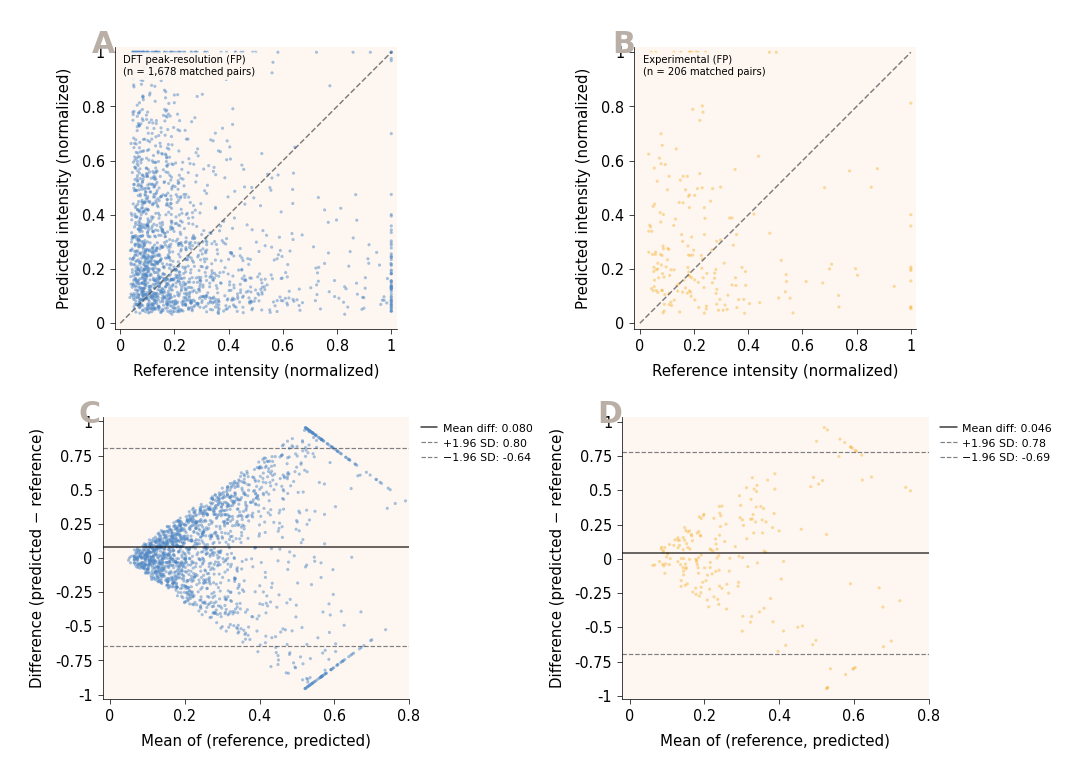

[Arcadia] fig6_intensity_agreement done


In [10]:
# === ARCADIA: Figure 6 — Intensity Agreement ===
src_int = next((c for c in ['source_int_norm', 'source_intensity'] if c in ll.columns), None)
tgt_int = next((c for c in ['target_int_norm', 'target_intensity'] if c in ll.columns), None)

fig, axes = arcadia_fig(2, 2, figsize=(15.6, 10.6))
panel_letters = [['A', 'B'], ['C', 'D']]

for col_idx, (bm, pair, region, title_str, color) in enumerate([
    ('dft_peak', 'DFT->Pred', 'fingerprint', 'DFT peak-resolution (FP)', AEGEAN),
    ('experimental_peak', 'Exp->Pred', 'fingerprint', 'Experimental (FP)', CANARY),
]):
    subset = ll[(ll['benchmark'] == bm) & (ll['pair'] == pair) &
                 (ll['region'] == region) & (ll['tol_cm'] == 10.0)]
    if len(subset) == 0:
        continue

    si = subset[src_int].dropna().values
    ti = subset[tgt_int].dropna().values
    n = min(len(si), len(ti))
    si, ti = si[:n], ti[:n]

    si_max = si.max() if si.max() > 0 else 1.0
    ti_max = ti.max() if ti.max() > 0 else 1.0
    si_norm = si / si_max
    ti_norm = ti / ti_max

    # Top row: Scatter
    ax = axes[0, col_idx]
    ax.scatter(si_norm, ti_norm, s=10, alpha=0.5, color=color, edgecolors='none', rasterized=True)
    ax.plot([0, 1], [0, 1], color=CHARCOAL, lw=1.5, ls='--', alpha=0.7)
    ax.set_xlabel('Reference intensity (normalized)', fontsize=15, fontweight='medium')
    ax.set_ylabel('Predicted intensity (normalized)', fontsize=15, fontweight='medium')
    ax.text(0.03, 0.97, f'{title_str}\n(n = {n:,} matched pairs)',
            transform=ax.transAxes, fontsize=10, ha='left', va='top',
            bbox=dict(boxstyle='round,pad=0.3', facecolor=PARCHMENT, edgecolor=CHATEAU, alpha=0.9))
    ax.set_xlim(-0.02, 1.02); ax.set_ylim(-0.02, 1.02)
    ax.set_aspect('equal')
    arcadia_style(ax, panel_letter=panel_letters[0][col_idx])

    # Bottom row: Bland-Altman
    ax = axes[1, col_idx]
    means = (si_norm + ti_norm) / 2
    diffs = ti_norm - si_norm
    mean_diff = np.mean(diffs)
    sd_diff = np.std(diffs)

    ax.scatter(means, diffs, s=10, alpha=0.5, color=color, edgecolors='none', rasterized=True)
    ax.axhline(mean_diff, color=A_BLACK, ls='-', lw=1.5, alpha=0.8, label=f'Mean diff: {mean_diff:.3f}')
    ax.axhline(mean_diff + 1.96*sd_diff, color=CHARCOAL, ls='--', lw=1.2, alpha=0.7,
               label=f'+1.96 SD: {mean_diff+1.96*sd_diff:.2f}')
    ax.axhline(mean_diff - 1.96*sd_diff, color=CHARCOAL, ls='--', lw=1.2, alpha=0.7,
               label=f'\u22121.96 SD: {mean_diff-1.96*sd_diff:.2f}')
    ax.set_xlabel('Mean of (reference, predicted)', fontsize=15, fontweight='medium')
    ax.set_ylabel('Difference (predicted \u2212 reference)', fontsize=15, fontweight='medium')
    ax.set_xlim(-0.02, 0.8)
    arcadia_style(ax, panel_letter=panel_letters[1][col_idx])
    arcadia_legend(ax, outside=True)

fig.tight_layout(pad=1.5)
fig.subplots_adjust(right=0.82)
fig.savefig(FIG_DIR / 'fig6_intensity_agreement_arcadia.png', dpi=300, bbox_inches='tight', facecolor='white')
fig.savefig(FIG_DIR / 'fig6_intensity_agreement_arcadia.svg', bbox_inches='tight', facecolor='white')
fig.savefig(FIG_DIR / 'fig6_intensity_agreement_arcadia.pdf', bbox_inches='tight', facecolor='white')
plt.show()
print('[Arcadia] fig6_intensity_agreement done')

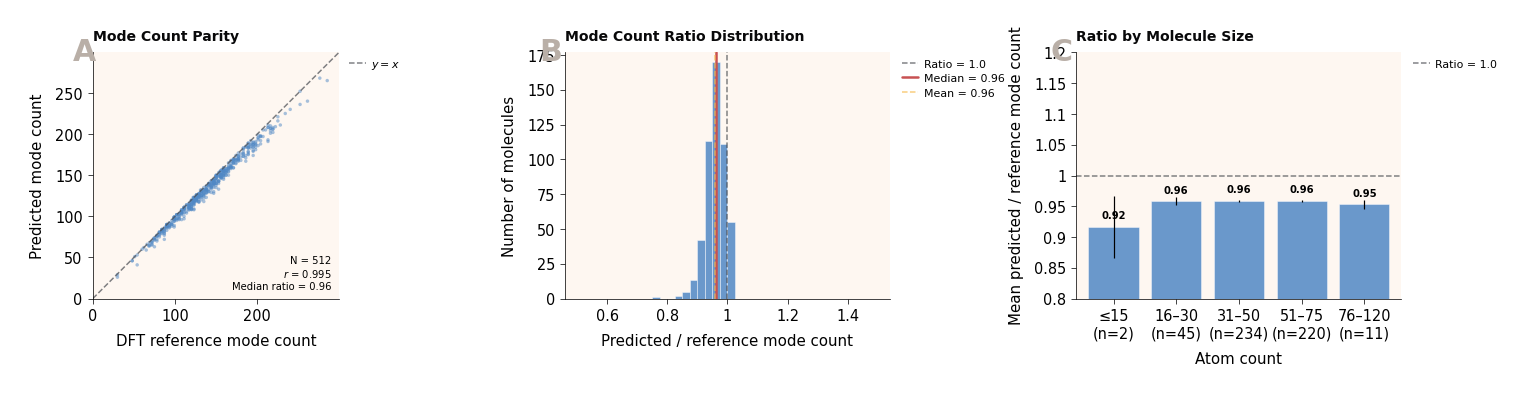

[Arcadia] fig7_mode_counts: N=512, median ratio=0.962


In [11]:
# === ARCADIA: Figure 7 — Mode Counts ===
dft_mc = pm[pm['benchmark_group'] == 'dft'].copy() if 'benchmark_group' in pm.columns else pd.DataFrame()

pred_counts = dft_mc['n_pred_modes'].dropna().values
ref_counts = dft_mc['n_dft_lines'].dropna().values
n_valid = min(len(pred_counts), len(ref_counts))
pred_counts = pred_counts[:n_valid]
ref_counts = ref_counts[:n_valid]

valid_mask = ref_counts > 0
ratios = pred_counts[valid_mask] / ref_counts[valid_mask]

fig, axes = arcadia_fig(1, 3, figsize=(23.5, 5.3))

# --- (a) Scatter: predicted vs reference mode counts ---
ax = axes[0]
ax.scatter(ref_counts, pred_counts, s=12, alpha=0.5, color=AEGEAN, edgecolors='none', rasterized=True)
max_val = max(ref_counts.max(), pred_counts.max()) * 1.05
ax.plot([0, max_val], [0, max_val], color=CHARCOAL, lw=1.5, ls='--', alpha=0.7, label='$y = x$')
ax.set_xlabel('DFT reference mode count', fontsize=15, fontweight='medium')
ax.set_ylabel('Predicted mode count', fontsize=15, fontweight='medium')
ax.set_xlim(0, max_val); ax.set_ylim(0, max_val)
ax.set_aspect('equal')
r_val, _ = pearsonr(ref_counts[valid_mask], pred_counts[valid_mask])
ax.text(0.97, 0.03,
        f'N = {valid_mask.sum()}\n$r$ = {r_val:.3f}\nMedian ratio = {np.median(ratios):.2f}',
        transform=ax.transAxes, fontsize=10, ha='right', va='bottom',
        bbox=dict(boxstyle='round,pad=0.4', facecolor=PARCHMENT, edgecolor=CHATEAU, alpha=0.9))
arcadia_style(ax, panel_letter='A')
ax.set_title('Mode Count Parity', fontsize=14, fontweight='semibold', color=A_BLACK, pad=12, loc='left')
arcadia_legend(ax, outside=True)

# --- (b) Histogram of pred/ref ratio ---
ax = axes[1]
ax.hist(ratios, bins=40, range=(0.5, 1.5), color=AEGEAN, alpha=0.85, edgecolor='white', linewidth=0.5)
med_ratio = np.median(ratios)
mean_ratio = np.mean(ratios)
ax.axvline(1.0, color=CHARCOAL, lw=1.5, ls='--', alpha=0.7, label='Ratio = 1.0')
ax.axvline(med_ratio, color=DRAGON, lw=2.5, ls='-',
           label=f'Median = {med_ratio:.2f}')
ax.axvline(mean_ratio, color=CANARY, lw=1.5, ls='--', alpha=0.7,
           label=f'Mean = {mean_ratio:.2f}')
ax.set_xlabel('Predicted / reference mode count', fontsize=15, fontweight='medium')
ax.set_ylabel('Number of molecules', fontsize=15, fontweight='medium')
arcadia_style(ax, panel_letter='B')
ax.set_title('Mode Count Ratio Distribution', fontsize=14, fontweight='semibold', color=A_BLACK, pad=12, loc='left')
arcadia_legend(ax, outside=True)

# --- (c) Summary bar chart: mean ratio by molecule size bin ---
ax = axes[2]
tmp = dft_mc[valid_mask.tolist()[:len(dft_mc)]].copy() if 'n_atoms' in dft_mc.columns else pd.DataFrame()
if 'n_atoms' in tmp.columns and len(tmp) > 0:
    tmp['ratio'] = tmp['n_pred_modes'] / tmp['n_dft_lines']
    tmp['size_bin'] = pd.cut(tmp['n_atoms'], bins=[0, 15, 30, 50, 75, 120],
                              labels=['\u226415', '16\u201330', '31\u201350', '51\u201375', '76\u2013120'])
    bin_stats = tmp.groupby('size_bin', observed=True)['ratio'].agg(['mean', 'median', 'std', 'count'])

    x = range(len(bin_stats))
    bars = ax.bar(x, bin_stats['mean'],
                  yerr=bin_stats['std'] / np.sqrt(bin_stats['count']),
                  color=AEGEAN, alpha=0.85, edgecolor='white', linewidth=0.5, capsize=4, error_kw={'lw': 1.2})
    ax.set_xticks(list(x))
    ax.set_xticklabels([f'{idx}\n(n={int(row["count"])})' for idx, row in bin_stats.iterrows()], fontsize=9)
    ax.axhline(1.0, color=CHARCOAL, lw=1.5, ls='--', alpha=0.7, label='Ratio = 1.0')
    ax.set_xlabel('Atom count', fontsize=15, fontweight='medium')
    ax.set_ylabel('Mean predicted / reference mode count', fontsize=15, fontweight='medium')
    ax.set_ylim(0.8, 1.2)
    for bar, val in zip(bars, bin_stats['mean']):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.2f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
else:
    ax.text(0.5, 0.5, 'n_atoms column not available', ha='center', va='center',
            transform=ax.transAxes, fontsize=11, color=MARINE)
arcadia_style(ax, panel_letter='C', comma_x=False)
ax.set_title('Ratio by Molecule Size', fontsize=14, fontweight='semibold', color=A_BLACK, pad=12, loc='left')
arcadia_legend(ax, outside=True)

fig.tight_layout(pad=1.5)
fig.subplots_adjust(right=0.82)
fig.savefig(FIG_DIR / 'fig7_mode_counts_arcadia.png', dpi=300, bbox_inches='tight', facecolor='white')
fig.savefig(FIG_DIR / 'fig7_mode_counts_arcadia.svg', bbox_inches='tight', facecolor='white')
fig.savefig(FIG_DIR / 'fig7_mode_counts_arcadia.pdf', bbox_inches='tight', facecolor='white')
plt.show()
print(f'[Arcadia] fig7_mode_counts: N={valid_mask.sum()}, median ratio={med_ratio:.3f}')

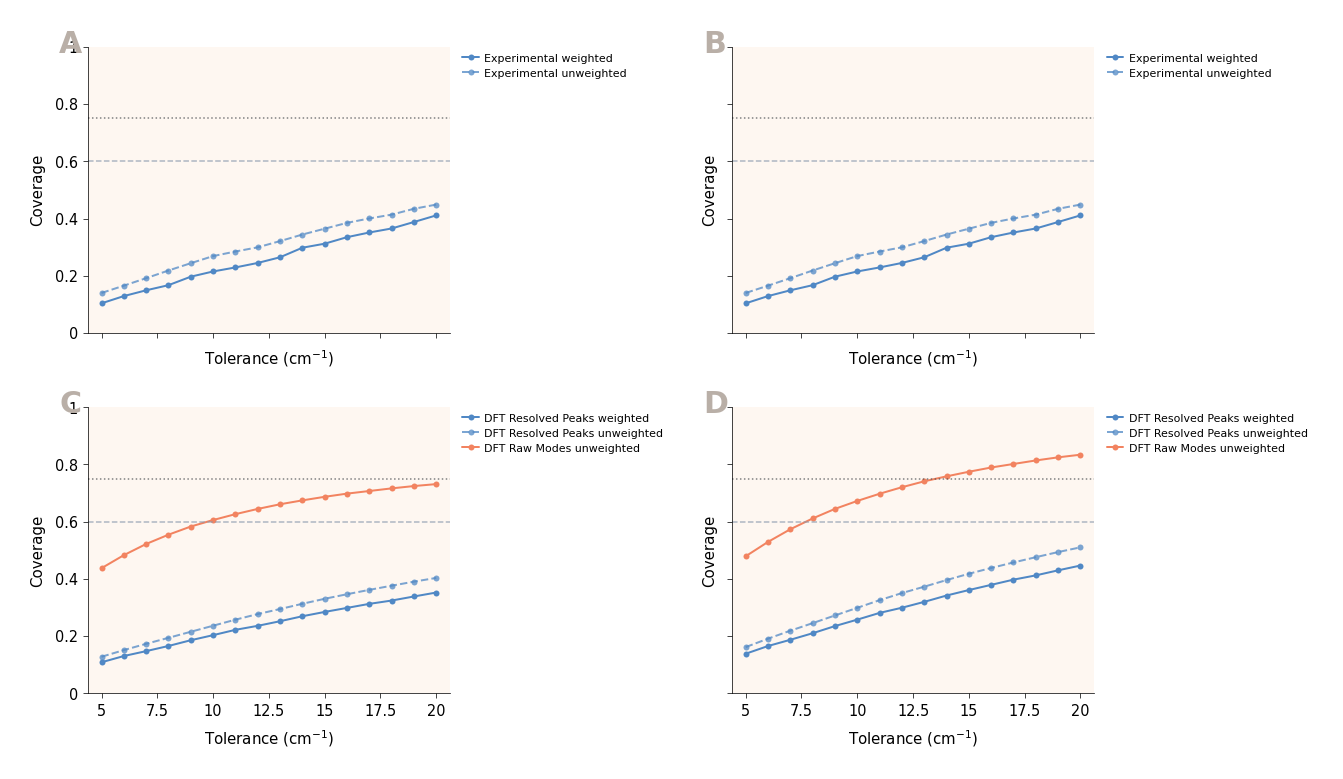

[Arcadia] fig8_tolerance_sweep done


In [12]:
# === ARCADIA: Figure 8 — Tolerance Sweep ===
fig, axes = arcadia_fig(2, 2, figsize=(18.4, 10.6), sharex=True, sharey=True)
panels = [
    (axes[0, 0], 'experimental_peak', 'Exp->Pred', 'measured_support', 'Experimental: measured support', 'A'),
    (axes[0, 1], 'experimental_peak', 'Exp->Pred', 'fingerprint', 'Experimental: fingerprint', 'B'),
    (axes[1, 0], None, 'DFT->Pred', 'full', 'DFT: full range', 'C'),
    (axes[1, 1], None, 'DFT->Pred', 'fingerprint', 'DFT: fingerprint', 'D'),
]
for ax, benchmark, pair, region, title, pletter in panels:
    if benchmark is None:
        data = pw[
            (pw['benchmark'].isin(['dft_peak', 'dft_raw_line']))
            & (pw['pair'] == pair)
            & (pw['region'] == region)
            & (pw['snr_bin'] == 'all')
        ].copy()
        for bench, grp in data.groupby('benchmark'):
            label = BENCHMARK_DISPLAY.get(bench, bench)
            grp = grp.sort_values('tol_cm')
            if bench == 'dft_peak':
                ax.plot(grp['tol_cm'], grp['global_weighted_coverage_any'], marker='o', ms=6,
                        lw=2, color=AEGEAN, label=f'{label} weighted')
                ax.plot(grp['tol_cm'], grp['global_coverage_any'], marker='o', ms=6,
                        lw=2, ls='--', alpha=0.75, color=AEGEAN, label=f'{label} unweighted')
            else:
                ax.plot(grp['tol_cm'], grp['global_coverage_any'], marker='o', ms=6,
                        lw=2, color=AMBER, label=f'{label} unweighted')
    else:
        data = pw[
            (pw['benchmark'] == benchmark)
            & (pw['pair'] == pair)
            & (pw['region'] == region)
            & (pw['snr_bin'] == 'all')
        ].copy().sort_values('tol_cm')
        if not data.empty:
            ax.plot(data['tol_cm'], data['global_weighted_coverage_any'], marker='o', ms=6,
                    lw=2, color=AEGEAN, label=f'{BENCHMARK_DISPLAY.get(benchmark, benchmark)} weighted')
            ax.plot(data['tol_cm'], data['global_coverage_any'], marker='o', ms=6,
                    lw=2, ls='--', alpha=0.75, color=AEGEAN, label=f'{BENCHMARK_DISPLAY.get(benchmark, benchmark)} unweighted')
    ax.axhline(0.75, color=CHARCOAL, ls=':', lw=1.5, alpha=0.7)
    ax.axhline(0.60, color=MARINE, ls='--', lw=1.5, alpha=0.7)
    ax.set_xlabel(r'Tolerance (cm$^{-1}$)', fontsize=15, fontweight='medium')
    ax.set_ylabel('Coverage', fontsize=15, fontweight='medium')
    ax.set_ylim(0.0, 1.0)
    arcadia_style(ax, panel_letter=pletter)
    if ax.get_legend_handles_labels()[0]:
        arcadia_legend(ax, outside=True)

fig.tight_layout(pad=1.5)
fig.subplots_adjust(right=0.82)
fig.savefig(FIG_DIR / 'fig8_tolerance_sweep_arcadia.png', dpi=300, bbox_inches='tight', facecolor='white')
fig.savefig(FIG_DIR / 'fig8_tolerance_sweep_arcadia.svg', bbox_inches='tight', facecolor='white')
fig.savefig(FIG_DIR / 'fig8_tolerance_sweep_arcadia.pdf', bbox_inches='tight', facecolor='white')
plt.show()
print('[Arcadia] fig8_tolerance_sweep done')

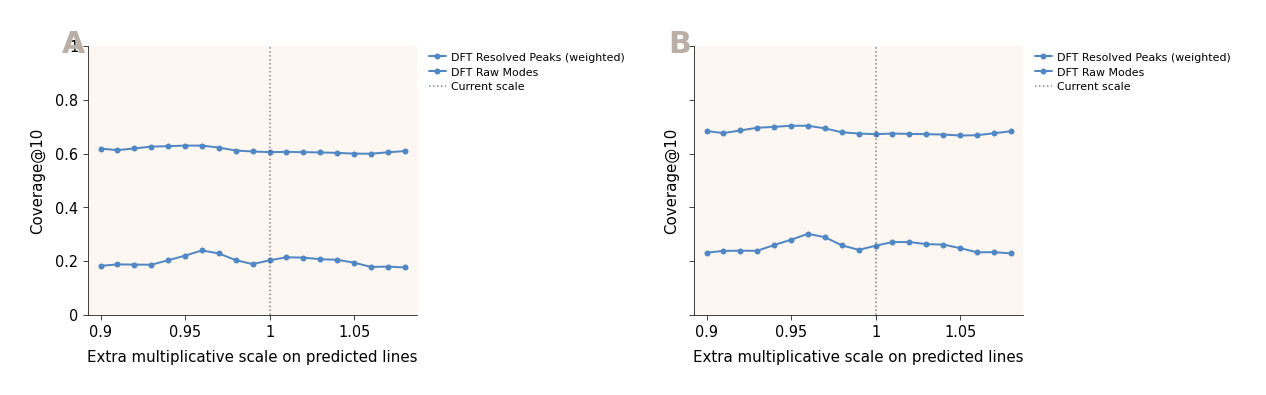

[Arcadia] fig9_scale_sweep done


In [13]:
# === ARCADIA: Figure 9 — Scale Sweep ===
plot_df = sc[(sc['pair'] == 'DFT->Pred') & (sc['region'].isin(['full', 'fingerprint']))].copy()

fig, axes = arcadia_fig(1, 2, figsize=(17.2, 5.3), sharey=True)
for idx, (ax, region) in enumerate(zip(axes, ['full', 'fingerprint'])):
    grp = plot_df[plot_df['region'] == region]
    if grp.empty:
        ax.set_visible(False)
        continue
    for benchmark, bench_grp in grp.groupby('benchmark'):
        y_col = 'global_weighted_coverage_any' if benchmark == 'dft_peak' else 'global_coverage_any'
        bench_grp = bench_grp.sort_values('scale_adjust')
        ax.plot(
            bench_grp['scale_adjust'],
            bench_grp[y_col],
            marker='o',
            ms=6,
            lw=2,
            color=AEGEAN,
            label=BENCHMARK_DISPLAY.get(benchmark, benchmark) + (' (weighted)' if benchmark == 'dft_peak' else ''),
        )
    ax.axvline(1.0, color=CHARCOAL, ls=':', lw=1.5, alpha=0.7, label='Current scale')
    ax.set_xlabel('Extra multiplicative scale on predicted lines', fontsize=15, fontweight='medium')
    ax.set_ylabel('Coverage@10', fontsize=15, fontweight='medium')
    ax.set_ylim(0.0, 1.0)
    arcadia_style(ax, panel_letter=chr(65 + idx))
    arcadia_legend(ax, outside=True)

fig.tight_layout(pad=1.5)
fig.subplots_adjust(right=0.82)
fig.savefig(FIG_DIR / 'fig9_scale_sweep_arcadia.png', dpi=300, bbox_inches='tight', facecolor='white')
fig.savefig(FIG_DIR / 'fig9_scale_sweep_arcadia.svg', bbox_inches='tight', facecolor='white')
fig.savefig(FIG_DIR / 'fig9_scale_sweep_arcadia.pdf', bbox_inches='tight', facecolor='white')
plt.show()
print('[Arcadia] fig9_scale_sweep done')

In [14]:
ES_DIR = REPO_ROOT / 'ramanchembl_pipeline' / 'alignment_results'
PAPER_FIG_DIR = Path('./output')

# Load the checkpoint evaluation data (this is what the actual figure uses)
ckpt = pd.read_csv(DATA_DIR / 'all_checkpoints_test.csv')
print(ckpt[['checkpoint', 'version', 'step']].to_string())

# Compute cumulative step: v8 steps as-is, v9 offset by v8 max, v10 offset by v8+v9 max
# First, get the ordered steps within each version
v8_max = ckpt[ckpt['version'] == 'v8']['step'].max()
v9_max = ckpt[ckpt['version'] == 'v9']['step'].max()

def cum_step(row):
    if row['version'] == 'none':
        return -50  # raw input, plot at left edge
    elif row['version'] == 'v8':
        return row['step'] if row['step'] >= 0 else 0
    elif row['version'] == 'v9':
        return v8_max + row['step']
    elif row['version'] == 'v10':
        return v8_max + v9_max + row['step']
    return row['step']

ckpt['cum_step'] = ckpt.apply(cum_step, axis=1)

# Remove raw_input for plotting (or plot separately)
raw_row = ckpt[ckpt['version'] == 'none']
plot_df = ckpt[ckpt['version'] != 'none'].sort_values('cum_step')


        checkpoint version  step
0        raw_input    none  -999
1   v8/phase1_best      v8    -1
2       v8/es_best      v8     0
3     v8/es_step50      v8    50
4    v8/es_step100      v8   100
5    v8/es_step150      v8   150
6    v8/es_step200      v8   200
7    v8/es_step250      v8   250
8    v8/es_step300      v8   300
9    v8/es_step350      v8   350
10   v8/es_step400      v8   400
11   v8/es_step450      v8   450
12   v8/es_step500      v8   500
13      v9/es_best      v9     0
14   v9/es_step100      v9   100
15   v9/es_step200      v9   200
16   v9/es_step300      v9   300
17   v9/es_step400      v9   400
18   v9/es_step500      v9   500
19   v9/es_step600      v9   600
20   v9/es_step700      v9   700
21   v9/es_step800      v9   800
22   v9/es_step900      v9   900
23  v9/es_step1000      v9  1000
24  v9/es_step1100      v9  1100
25  v9/es_step1200      v9  1200
26  v9/es_step1300      v9  1300
27  v9/es_step1400      v9  1400
28  v9/es_step1500      v9  1500
29     v10

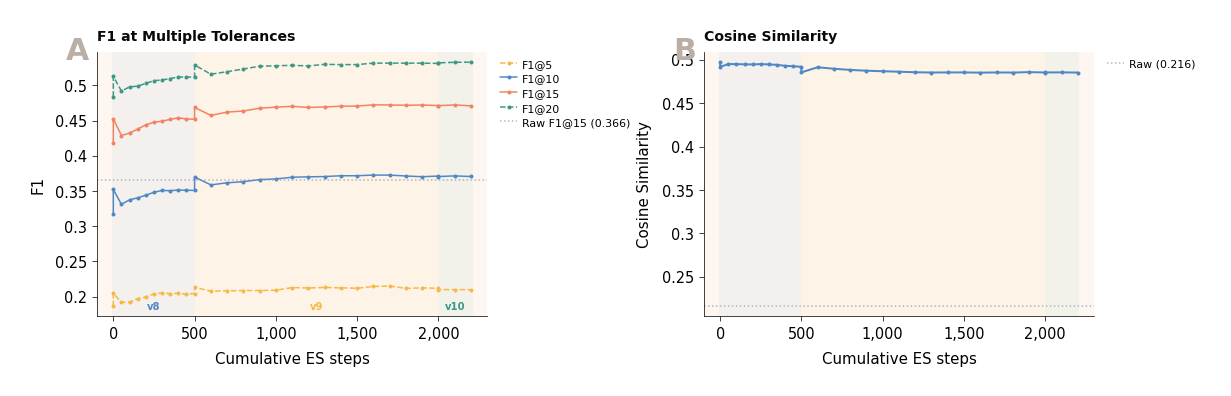

[Arcadia] fig10_es_convergence done


In [15]:
# === ARCADIA: Figure 10 — ES Convergence ===
# Re-use ckpt, plot_df, raw_row, v8_max, v9_max from the cell above

fig, (ax1, ax2) = arcadia_fig(1, 2, figsize=(18.4, 5.3))

# LEFT: F1 at multiple tolerances
for col, label, color, ls in [
    ('f1@5', 'F1@5', CANARY, '--'),
    ('f1@10', 'F1@10', AEGEAN, '-'),
    ('f1@15', 'F1@15', AMBER, '-'),
    ('f1@20', 'F1@20', SEAWEED, '--'),
]:
    ax1.plot(plot_df['cum_step'], plot_df[col], marker='o', ms=4, color=color, lw=1.5, ls=ls, label=label)

# Raw baseline
if len(raw_row) > 0:
    raw_f15 = raw_row['f1@15'].values[0]
    ax1.axhline(raw_f15, color=MARINE, ls=':', lw=1.5, alpha=0.7, label=f'Raw F1@15 ({raw_f15:.3f})')

# Version boundaries with light tint backgrounds
v8_end = v8_max
v9_end = v8_max + v9_max
ax1.axvspan(plot_df['cum_step'].min() - 10, v8_end, alpha=0.06, color=AEGEAN)
ax1.axvspan(v8_end, v9_end, alpha=0.06, color=CANARY)
ax1.axvspan(v9_end, plot_df['cum_step'].max() + 10, alpha=0.06, color=SEAWEED)
ax1.text(v8_end / 2, ax1.get_ylim()[0] + 0.01, 'v8', ha='center', fontsize=10, color=AEGEAN, fontweight='semibold')
ax1.text((v8_end + v9_end) / 2, ax1.get_ylim()[0] + 0.01, 'v9', ha='center', fontsize=10, color=CANARY, fontweight='semibold')
ax1.text((v9_end + plot_df['cum_step'].max()) / 2, ax1.get_ylim()[0] + 0.01, 'v10', ha='center', fontsize=10, color=SEAWEED, fontweight='semibold')

ax1.set_xlabel('Cumulative ES steps', fontsize=15, fontweight='medium')
ax1.set_ylabel('F1', fontsize=15, fontweight='medium')
arcadia_style(ax1, panel_letter='A')
ax1.set_title('F1 at Multiple Tolerances', fontsize=14, fontweight='semibold', color=A_BLACK, pad=12, loc='left')
arcadia_legend(ax1, outside=True)

# RIGHT: Cosine similarity
ax2.plot(plot_df['cum_step'], plot_df['cosine'], marker='o', ms=4, color=AEGEAN, lw=2)
if len(raw_row) > 0:
    raw_cos = raw_row['cosine'].values[0]
    ax2.axhline(raw_cos, color=MARINE, ls=':', lw=1.5, alpha=0.7, label=f'Raw ({raw_cos:.3f})')

ax2.axvspan(plot_df['cum_step'].min() - 10, v8_end, alpha=0.06, color=AEGEAN)
ax2.axvspan(v8_end, v9_end, alpha=0.06, color=CANARY)
ax2.axvspan(v9_end, plot_df['cum_step'].max() + 10, alpha=0.06, color=SEAWEED)

ax2.set_xlabel('Cumulative ES steps', fontsize=15, fontweight='medium')
ax2.set_ylabel('Cosine Similarity', fontsize=15, fontweight='medium')
arcadia_style(ax2, panel_letter='B')
ax2.set_title('Cosine Similarity', fontsize=14, fontweight='semibold', color=A_BLACK, pad=12, loc='left')
arcadia_legend(ax2, outside=True)

fig.tight_layout(pad=1.5)
fig.subplots_adjust(right=0.82)
fig.savefig(FIG_DIR / 'fig10_es_convergence_arcadia.png', dpi=300, bbox_inches='tight', facecolor='white')
fig.savefig(FIG_DIR / 'fig10_es_convergence_arcadia.svg', bbox_inches='tight', facecolor='white')
fig.savefig(FIG_DIR / 'fig10_es_convergence_arcadia.pdf', bbox_inches='tight', facecolor='white')
plt.show()
print('[Arcadia] fig10_es_convergence done')

In [16]:
from scipy.signal import find_peaks

# Load best available test predictions (v10 if exists, else v8)
for ver in ['refinement_v10', 'refinement_v8']:
    npz_path = ES_DIR / ver / 'test_preds.npz'
    if npz_path.exists():
        d = np.load(npz_path)
        print(f'Loaded {ver}: refined={d["refined"].shape}, raw={d["raw"].shape}, target={d["target"].shape}')
        break

refined = d['refined']
raw = d['raw']
target = d['target']
x_grid = d['x_grid']

# F1 calculation (greedy matching, same as train_refinement_modal.py)
def _extract(s):
    p, _ = find_peaks(s, prominence=0.02, height=0.01, distance=5)
    return x_grid[p]

def _f1(ref_peaks, pred_peaks, tol=15.0):
    if len(ref_peaks) == 0 or len(pred_peaks) == 0:
        return 0.0
    matched = set()
    tp = 0
    for p in pred_peaks:
        dists = np.abs(ref_peaks - p)
        for i in np.argsort(dists):
            if dists[i] > tol:
                break
            if i not in matched:
                matched.add(i)
                tp += 1
                break
    prec = tp / len(pred_peaks)
    rec = tp / len(ref_peaks)
    return 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0.0

# Compute per-molecule F1@15
n_mol = len(refined)
f1_raw = np.array([_f1(_extract(target[i]), _extract(raw[i])) for i in range(n_mol)])
f1_ref = np.array([_f1(_extract(target[i]), _extract(refined[i])) for i in range(n_mol)])
improvement = f1_ref - f1_raw

# Top 8 by improvement
sort_idx = np.argsort(-improvement)


Loaded refinement_v10: refined=(150, 3501), raw=(150, 3501), target=(150, 3501)


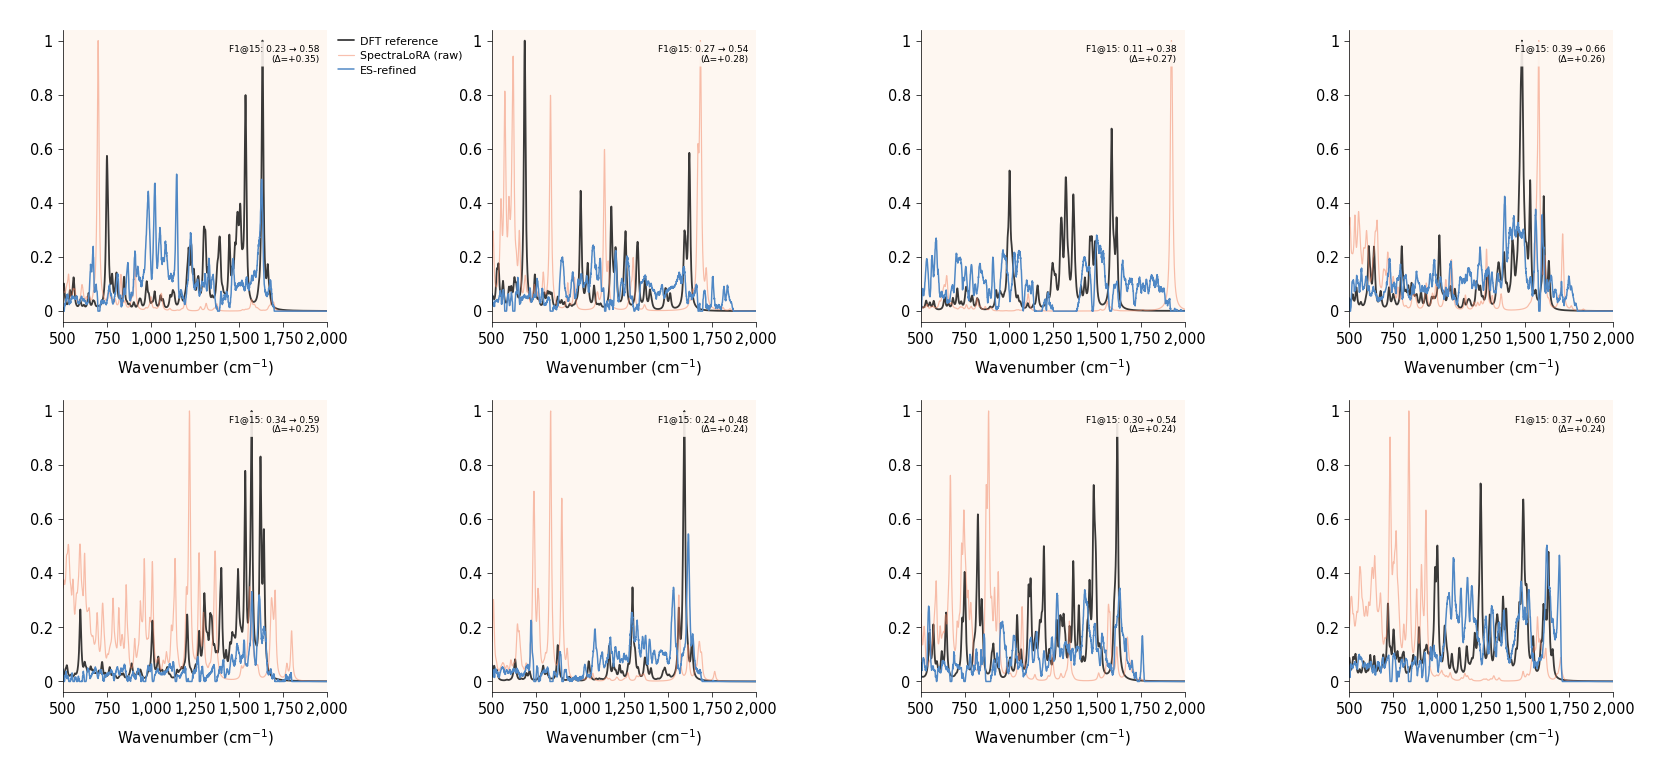

[Arcadia] fig11_es_before_after done


In [17]:
# === ARCADIA: Figure 11 — ES Before/After Spectral Comparison ===
# Re-use refined, raw, target, x_grid, f1_raw, f1_ref, improvement, sort_idx from the cell above

fig, axes = arcadia_fig(2, 4, figsize=(27.2, 10.6))
for panel, ax in enumerate(axes.flat):
    i = sort_idx[panel]
    ax.plot(x_grid, target[i], color=A_BLACK, lw=1.8, alpha=0.8, label='DFT reference')
    ax.plot(x_grid, raw[i], color=AMBER, lw=1.2, alpha=0.5, label='SpectraLoRA (raw)')
    ax.plot(x_grid, refined[i], color=AEGEAN, lw=1.5, label='ES-refined')
    ax.set_xlim(500, 2000)
    ax.set_xlabel(r'Wavenumber (cm$^{-1}$)', fontsize=15, fontweight='medium')
    ax.text(0.97, 0.95, f'F1@15: {f1_raw[i]:.2f} \u2192 {f1_ref[i]:.2f}\n(\u0394={improvement[i]:+.2f})',
            transform=ax.transAxes, fontsize=9, ha='right', va='top',
            bbox=dict(boxstyle='round,pad=0.3', facecolor=PARCHMENT, edgecolor=CHATEAU, alpha=0.9))
    arcadia_style(ax)
    if panel == 0:
        arcadia_legend(ax, outside=True)

fig.tight_layout(pad=1.5)
fig.subplots_adjust(right=0.82)
fig.savefig(FIG_DIR / 'fig11_es_before_after_arcadia.png', dpi=300, bbox_inches='tight', facecolor='white')
fig.savefig(FIG_DIR / 'fig11_es_before_after_arcadia.svg', bbox_inches='tight', facecolor='white')
fig.savefig(FIG_DIR / 'fig11_es_before_after_arcadia.pdf', bbox_inches='tight', facecolor='white')
plt.show()
print('[Arcadia] fig11_es_before_after done')

In [18]:
# Broadened overlays — 2x4 grid
# Top: experimental | Bottom: DFT
# Selection: coverage@10 from raw mode frequencies (DFT) or peak-extracted (exp)
# Matching original _select_representative_cases: 0.75*cov + 0.25*cos, percentiles 0/40/60/100

CACHE_DIR = REPO_ROOT / 'ramanchembl_pipeline' / 'artifacts' / 'alignment' / 'cache'

# --- Load DFT (1000 mol, raw freqs + broadened spectra) ---
dft_data = np.load(CACHE_DIR / 'dft_point_v1_1000.npz', allow_pickle=True)
dft_pred_spec = dft_data['y_pred_spec']    # (1000, 3501)
dft_tgt_spec = dft_data['y_target_spec']   # (1000, 3501)
dft_xgrid = dft_data['x_grid']            # (3501,)
dft_pred_freq = dft_data['pred_freq']      # (1000, 278)
dft_pred_mask = dft_data['pred_mask']      # (1000, 278)
dft_tgt_freq = dft_data['target_freq']     # (1000, 282)
dft_tgt_mask = dft_data['target_mask']     # (1000, 282)

# --- Load Experimental (89 mol, broadened only) ---
exp_data = np.load(CACHE_DIR / 'exp_point_v1_202.npz', allow_pickle=True)
exp_pred_spec = exp_data['y_pred']
exp_tgt_spec = exp_data['y_target']
exp_xgrid = exp_data['x_grid']
exp_mask_arr = exp_data['mask']

n_dft = len(dft_pred_spec)
n_exp = len(exp_pred_spec)
print(f'DFT: {n_dft} mol | Exp: {n_exp} mol')

# --- DFT coverage from raw frequencies (nearest-neighbor, tol=10) ---
def raw_coverage(pred_f, pred_m, tgt_f, tgt_m, tol=10.0):
    scores = []
    for i in range(len(pred_f)):
        pf = pred_f[i][pred_m[i] > 0]
        tf = tgt_f[i][tgt_m[i] > 0]
        if len(tf) == 0:
            scores.append(0.0)
            continue
        if len(pf) == 0:
            scores.append(0.0)
            continue
        dists = np.abs(tf[:, None] - pf[None, :])
        nearest = dists.min(axis=1)
        scores.append(float(np.mean(nearest <= tol)))
    return np.array(scores)

cov_dft = raw_coverage(dft_pred_freq, dft_pred_mask, dft_tgt_freq, dft_tgt_mask, tol=10.0)

# --- Exp coverage from peak-extracted broadened spectra ---
from scipy.signal import find_peaks

def spec_coverage(pred_spec, tgt_spec, xgrid, tol=10.0, mask=None):
    scores = []
    for i in range(len(pred_spec)):
        t = tgt_spec[i].copy()
        p = pred_spec[i].copy()
        if mask is not None:
            t = t * mask[i]
            p = p * mask[i]
        mx_t = t.max()
        mx_p = p.max()
        t_n = t / mx_t if mx_t > 0 else t
        p_n = p / mx_p if mx_p > 0 else p
        tp, _ = find_peaks(t_n, prominence=0.02, height=0.01, distance=5)
        pp, _ = find_peaks(p_n, prominence=0.02, height=0.01, distance=5)
        if len(tp) == 0:
            scores.append(0.0)
            continue
        tf = xgrid[tp]
        pf = xgrid[pp]
        if len(pf) == 0:
            scores.append(0.0)
            continue
        dists = np.abs(tf[:, None] - pf[None, :])
        nearest = dists.min(axis=1)
        scores.append(float(np.mean(nearest <= tol)))
    return np.array(scores)

cov_exp = spec_coverage(exp_pred_spec, exp_tgt_spec, exp_xgrid, tol=10.0, mask=exp_mask_arr)

# --- Cosine similarity ---
def cosine(a, b):
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b) + 1e-12)

cos_dft = np.array([cosine(dft_pred_spec[i], dft_tgt_spec[i]) for i in range(n_dft)])
cos_exp = np.array([cosine(exp_pred_spec[i] * exp_mask_arr[i], exp_tgt_spec[i] * exp_mask_arr[i]) for i in range(n_exp)])

# --- Blended score: 0.75*cov_norm + 0.25*cos_norm (matching original) ---
def blended_select(cov, cos, n):
    cov_norm = (cov - cov.min()) / max(cov.max() - cov.min(), 1e-8)
    cos_fill = np.where(np.isfinite(cos), cos, np.nanmedian(cos))
    cos_norm = (cos_fill - cos_fill.min()) / max(cos_fill.max() - cos_fill.min(), 1e-8)
    score = 0.75 * cov_norm + 0.25 * cos_norm
    idx = np.argsort(score)
    percentiles = [0.0, 0.4, 0.6, 1.0]
    return [idx[int(round(p * (n - 1)))] for p in percentiles], score

dft_sel, dft_score = blended_select(cov_dft, cos_dft, n_dft)
exp_sel, exp_score = blended_select(cov_exp, cos_exp, n_exp)

labels = ['very weak', 'ok-1', 'ok-2', 'very good']


DFT: 1000 mol | Exp: 89 mol


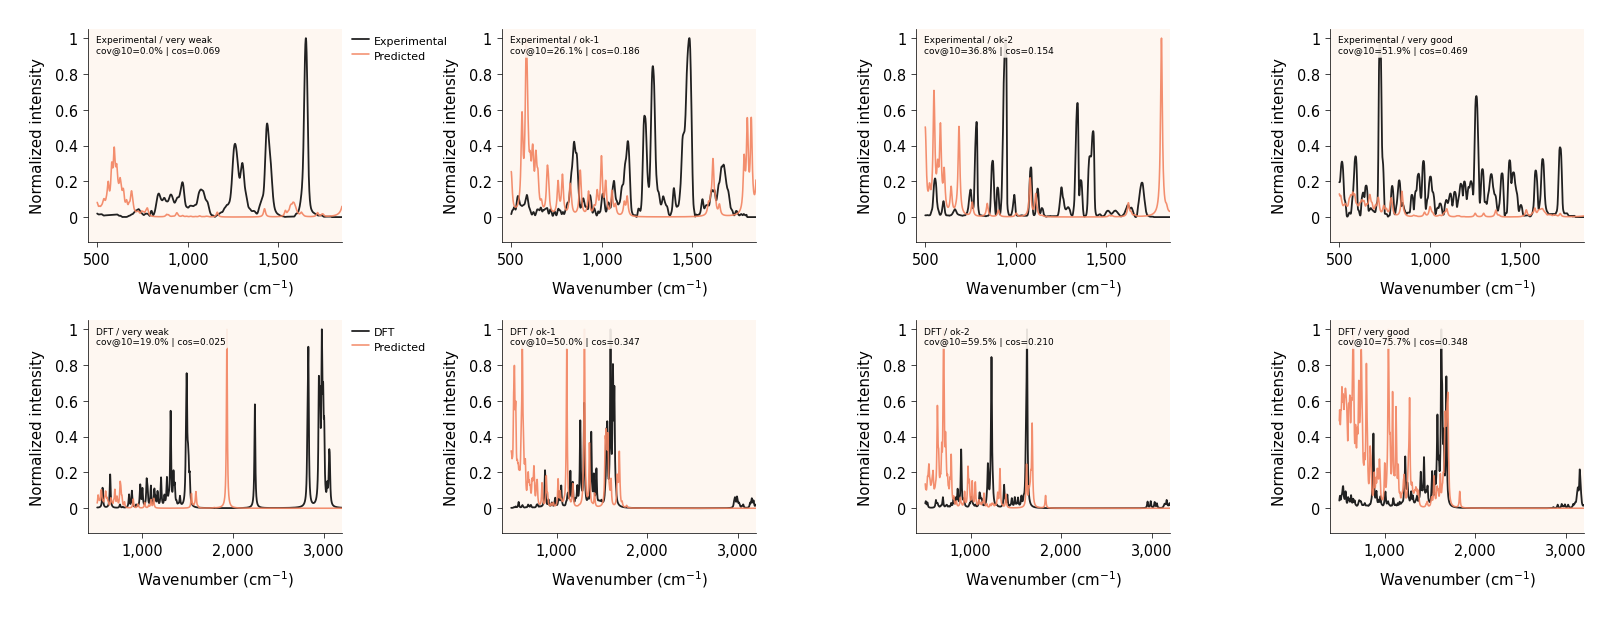

[Arcadia] fig12_broadened_overlays done


In [19]:
# === ARCADIA: Figure 12 — Broadened Spectral Overlays ===
# Re-use all data loaded in the cell above: exp/dft spectra, selections, coverage, cosine, etc.

def norm_spec(s):
    mx = s.max()
    return s / mx if mx > 0 else s

fig, axes = arcadia_fig(2, 4, figsize=(26.7, 8.4))

# Top row: experimental
for col_idx, (idx, label) in enumerate(zip(exp_sel, labels)):
    ax = axes[0, col_idx]
    ax.plot(exp_xgrid, norm_spec(exp_tgt_spec[idx]), color=A_BLACK, lw=1.8, alpha=0.9, label='Experimental')
    ax.plot(exp_xgrid, norm_spec(exp_pred_spec[idx]), color=AMBER, lw=1.6, alpha=0.9, label='Predicted')
    support = exp_mask_arr[idx] > 0
    if support.any():
        ax.set_xlim(exp_xgrid[support].min() - 50, exp_xgrid[support].max() + 50)
    ax.set_ylim(-0.14, 1.05)
    ax.text(0.03, 0.97, f'Experimental / {label}\ncov@10={cov_exp[idx]:.1%} | cos={cos_exp[idx]:.3f}',
            transform=ax.transAxes, fontsize=9, ha='left', va='top',
            bbox=dict(boxstyle='round,pad=0.3', facecolor=PARCHMENT, edgecolor=CHATEAU, alpha=0.9))
    ax.set_xlabel(r'Wavenumber (cm$^{-1}$)', fontsize=15, fontweight='medium')
    ax.set_ylabel('Normalized intensity', fontsize=15, fontweight='medium')
    arcadia_style(ax)
    if col_idx == 0:
        arcadia_legend(ax, outside=True)

# Bottom row: DFT
for col_idx, (idx, label) in enumerate(zip(dft_sel, labels)):
    ax = axes[1, col_idx]
    ax.plot(dft_xgrid, norm_spec(dft_tgt_spec[idx]), color=A_BLACK, lw=1.8, alpha=0.9, label='DFT')
    ax.plot(dft_xgrid, norm_spec(dft_pred_spec[idx]), color=AMBER, lw=1.6, alpha=0.9, label='Predicted')
    pf = dft_pred_freq[idx][dft_pred_mask[idx] > 0]
    tf = dft_tgt_freq[idx][dft_tgt_mask[idx] > 0]
    all_f = np.concatenate([pf, tf])
    if len(all_f) > 0:
        ax.set_xlim(max(400, all_f.min() - 75), min(3200, all_f.max() + 75))
    ax.set_ylim(-0.14, 1.05)
    ax.text(0.03, 0.97, f'DFT / {label}\ncov@10={cov_dft[idx]:.1%} | cos={cos_dft[idx]:.3f}',
            transform=ax.transAxes, fontsize=9, ha='left', va='top',
            bbox=dict(boxstyle='round,pad=0.3', facecolor=PARCHMENT, edgecolor=CHATEAU, alpha=0.9))
    ax.set_xlabel(r'Wavenumber (cm$^{-1}$)', fontsize=15, fontweight='medium')
    ax.set_ylabel('Normalized intensity', fontsize=15, fontweight='medium')
    arcadia_style(ax)
    if col_idx == 0:
        arcadia_legend(ax, outside=True)

fig.tight_layout(pad=1.5)
fig.subplots_adjust(right=0.82)
fig.savefig(FIG_DIR / 'fig12_broadened_overlays_arcadia.png', dpi=300, bbox_inches='tight', facecolor='white')
fig.savefig(FIG_DIR / 'fig12_broadened_overlays_arcadia.svg', bbox_inches='tight', facecolor='white')
fig.savefig(FIG_DIR / 'fig12_broadened_overlays_arcadia.pdf', bbox_inches='tight', facecolor='white')
plt.show()
print('[Arcadia] fig12_broadened_overlays done')

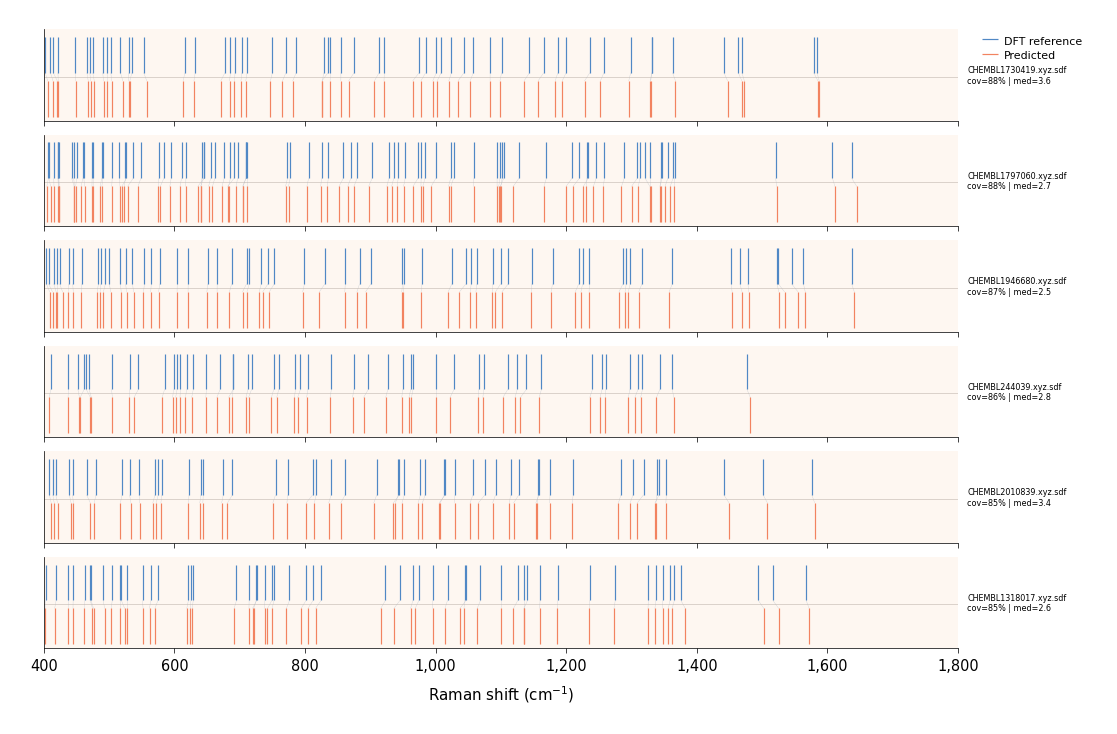

[Arcadia] fig13_barcode done


In [20]:
# Barcode plot — top 6 DFT molecules by fingerprint coverage@10
cov_col = 'coverage_any__dft_raw_line__DFT->Pred__fingerprint__tol_10'
top6 = dft_pm.nlargest(6, cov_col)[['case_id', 'component', cov_col]].reset_index(drop=True)

dft_lines = ll[
    (ll['benchmark'] == 'dft_raw_line') &
    (ll['pair'] == 'DFT->Pred') &
    (ll['region'] == 'fingerprint') &
    (ll['tol_cm'] == 10.0) &
    (ll['case_id'].isin(top6['case_id']))
]

case_ids   = top6['case_id'].tolist()
case_names = dict(zip(top6['case_id'], top6['component']))
case_covs  = dict(zip(top6['case_id'], top6[cov_col]))

# === ARCADIA: Figure 13 — Barcode Plot (DFT best) ===
# Re-use top6, dft_lines, case_ids, case_names, case_covs from the cell above

fig, axes = arcadia_fig(6, 1, figsize=(16.1, 10.0), sharex=True)
# arcadia_fig returns (fig, axes) -- for 6x1 axes is already a 1D array

for ax, cid in zip(axes, case_ids):
    sub = dft_lines[dft_lines['case_id'] == cid]
    src = sub['source_freq_cm'].values
    tgt = sub['target_freq_cm'].values
    errs = sub['signed_dnu_cm'].values

    ax.vlines(src, 0.55, 1.0, colors=AEGEAN, lw=1.2, label='DFT reference' if ax == axes[0] else None)
    ax.vlines(tgt, 0.0, 0.45, colors=AMBER, lw=1.2, label='Predicted' if ax == axes[0] else None)
    for s, t in zip(src, tgt):
        ax.plot([s, t], [0.55, 0.45], color=MARINE, lw=0.4, alpha=0.4)

    ax.axhline(0.5, color=CHATEAU, lw=0.5)
    ax.set_ylim(-0.05, 1.1)
    ax.set_yticks([])

    name = str(case_names.get(cid, cid))[:35]
    cov = case_covs.get(cid, 0)
    med_err = np.median(np.abs(errs)) if len(errs) > 0 else float('nan')
    ax.text(1.01, 0.5, f'{name}\ncov={cov:.0%} | med={med_err:.1f}',
            transform=ax.transAxes, va='center', ha='left', fontsize=8)
    arcadia_style(ax)

arcadia_legend(axes[0], outside=True)
axes[-1].set_xlabel(r'Raman shift (cm$^{-1}$)', fontsize=15, fontweight='medium')
axes[-1].set_xlim(400, 1800)

fig.tight_layout(pad=1.5)
fig.subplots_adjust(hspace=0.15, right=0.82)

fig.savefig(FIG_DIR / 'fig13_barcode_arcadia.png', dpi=300, bbox_inches='tight', facecolor='white')
fig.savefig(FIG_DIR / 'fig13_barcode_arcadia.svg', bbox_inches='tight', facecolor='white')
fig.savefig(FIG_DIR / 'fig13_barcode_arcadia.pdf', bbox_inches='tight', facecolor='white')
plt.show()
print('[Arcadia] fig13_barcode done')

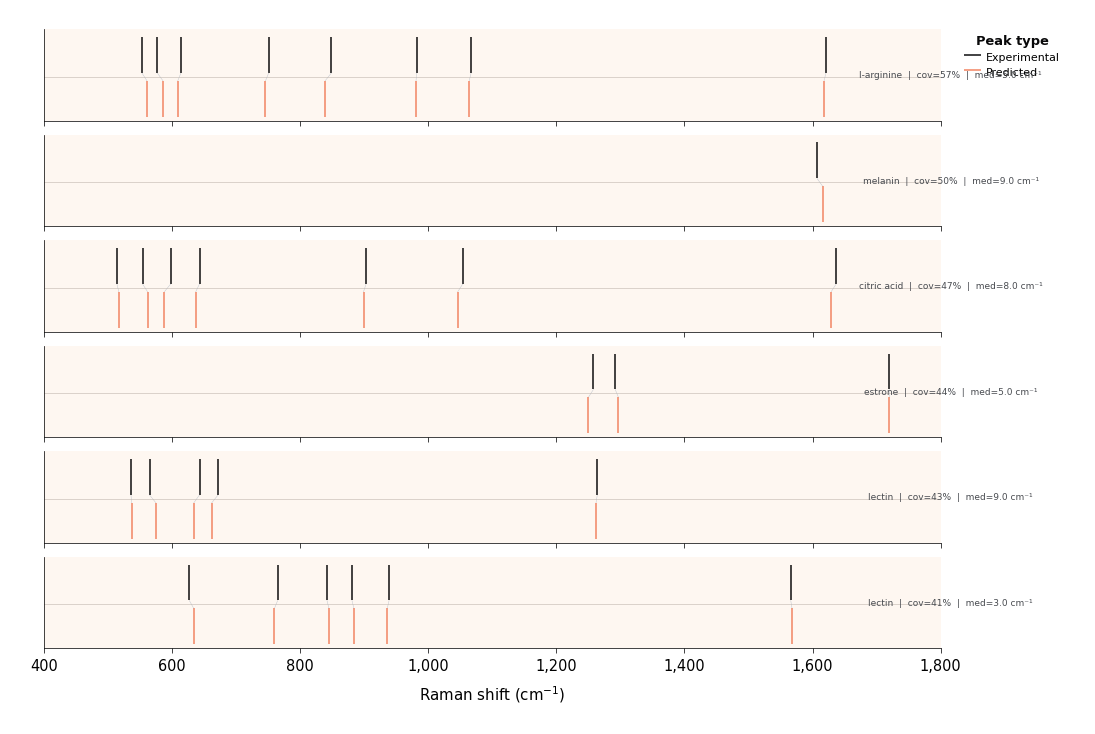

[Arcadia] Experimental barcode: top-6 molecules by coverage@10


In [21]:
# === ARCADIA: Figure 14 — Experimental Barcode Plot ===
exp_cov_col = 'coverage_any__experimental_peak__Exp->Pred__measured_support__tol_10'
exp_top6 = exp_pm.nlargest(6, exp_cov_col)[['case_id', 'component', exp_cov_col]].reset_index(drop=True)

# Get matched lines for these molecules
exp_barcode_lines = ll[
    (ll['benchmark'] == 'experimental_peak') &
    (ll['pair'] == 'Exp->Pred') &
    (ll['region'] == 'measured_support') &
    (ll['tol_cm'] == 10.0) &
    (ll['case_id'].isin(exp_top6['case_id']))
]

exp_case_ids = exp_top6['case_id'].tolist()
exp_case_names = dict(zip(exp_top6['case_id'], exp_top6['component']))
exp_case_covs = dict(zip(exp_top6['case_id'], exp_top6[exp_cov_col]))

fig, axes = arcadia_fig(6, 1, figsize=(18, 10.0), sharex=True)

for ax, cid in zip(axes, exp_case_ids):
    sub = exp_barcode_lines[exp_barcode_lines['case_id'] == cid]
    src_freqs = sub['source_freq_cm'].values
    tgt_freqs = sub['target_freq_cm'].values
    errs = sub['signed_dnu_cm'].values

    # Experimental reference on top (black), predicted on bottom (amber)
    ax.vlines(src_freqs, 0.55, 1.0, colors=A_BLACK, lw=1.5, label='Experimental' if ax == axes[0] else None)
    ax.vlines(tgt_freqs, 0.0, 0.45, colors=AMBER, lw=1.5, label='Predicted' if ax == axes[0] else None)
    
    # Gray connectors
    for s, t in zip(src_freqs, tgt_freqs):
        ax.plot([s, t], [0.55, 0.45], color=MARINE, lw=0.5, alpha=0.5)

    ax.axhline(0.5, color=CHATEAU, lw=0.5)
    ax.set_ylim(-0.05, 1.1)
    ax.set_yticks([])

    name = str(exp_case_names.get(cid, cid))[:30]
    cov = exp_case_covs.get(cid, 0)
    med_err = np.median(np.abs(errs)) if len(errs) > 0 else float('nan')
    # Use ylabel on the right side instead of text annotation
    ax2 = ax.twinx()
    ax2.set_yticks([])
    ax2.spines['top'].set_visible(False)
    ax2.spines['right'].set_visible(False)
    ax2.spines['left'].set_visible(False)
    ax2.spines['bottom'].set_visible(False)
    ax2.set_ylabel(f'{name}  |  cov={cov:.0%}  |  med={med_err:.1f} cm⁻¹',
                    fontsize=9, color=CHARCOAL, rotation=0, labelpad=10, va='center')
    
    arcadia_style(ax)

arcadia_legend(axes[0], title='Peak type', outside=True)
axes[-1].set_xlabel(r'Raman shift (cm$^{-1}$)', fontsize=15, fontweight='medium')
axes[-1].set_xlim(400, 1800)

fig.tight_layout(pad=1.5)
fig.subplots_adjust(hspace=0.15, right=0.72)

fig.savefig(FIG_DIR / 'fig14_barcode_experimental_arcadia.png', dpi=300, bbox_inches='tight', facecolor='white')
fig.savefig(FIG_DIR / 'fig14_barcode_experimental_arcadia.svg', bbox_inches='tight', facecolor='white')
fig.savefig(FIG_DIR / 'fig14_barcode_experimental_arcadia.pdf', bbox_inches='tight', facecolor='white')
plt.show()
print(f'[Arcadia] Experimental barcode: top-6 molecules by coverage@10')